# Deep Learning for Robotics Assignment 1 - Behavioral Cloning

This assignment will give you a tutorial on behavioral cloning, a very important tool for robot learning.  Behvioral cloning allows us to learn policies from datasets of previously collected demonstrations.  This is very powerful for a number of reasons.  First, these offline approaches do not require environment interactions (we do not need to query the environment for rewards as you need to do with Reinforcement Learning).  For robotics this is particularly helpful as environment interaction can be expensive or dangerous.  Even more importantly, offline approaches are necessary for robot learning as they allow for much greater scalability and portability (which is exactly what we are looking for in this era of deep learning).  Datasets of demonstrations can be shared across institutions and grown over time (think RT-X dataset).  These large scale datasets can help bring robotics closer to the successes of computer vision and NLP.  If you work in robotics you may realize that this is not exactly how things currently work, datasets are often not reused and it is very common to collect new data for every experiment.  This is exactly why we need better methods for behavioral cloning.  Learning effictive policies from diverse demonstration datasets is a very active area of research.

**Robomimic:** Robomimic is an open source platform for imitation learning algorithms and datasets.  The platform's foundational study paper investigates a variety of offline learning algorithms across a suite of demonstrated tasks (provided by real humans of differing skill levels).  The authors draw insights about algorithm design and dataset characterists from the results in this paper.  You will be using the robomimic codebase and datasets for this project.  At the end of the assignment you will conduct your own experiments and draw your own lessons about three key behavioral cloning algorithms.  You will read the robomimic paper (https://arxiv.org/abs/2108.03298) for the class on 2/14.

**Robosuite:** "Rososuite is a simulation framework powered by the MuJoCo physics engine for robot learning. It also offers a suite of benchmark environments for reproducible research."  This is the simulation environment upon which robomimic is build.
Here is the robosuite paper (https://arxiv.org/abs/2009.12293).

### Imports and Environment Setup

1. Download the DLM folder from canvas and upload it to your google drive.  It should contain DLM_A1.ipynb (this notebook), helper.py, and helper_models.py.

2. Click on this notebook in your google drive and open it with google colab.

3. Mount your google drive so that you can access the DLM folder

In [ ]:
# mount your google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


4. Install necessary packages

In [ ]:
%%capture
# install the necessary packages
!git clone https://github.com/ARISE-Initiative/robomimic
!pip install -e robomimic/
!git clone https://github.com/ARISE-Initiative/robosuite
!pip install mujoco
!pip install egl-probe


5. Add robomimic and robosuite to the system path.  Also make sure the path_to_dlm is set correctly, this should point to the location of the DLM folder in your google drive

In [ ]:
import os
import sys

# change path to your DLM folder
path_to_dlm = '/content/drive/MyDrive/Dhruv_Professional/GeorgiaTech/DLM/'#'./'

sys.path.append(path_to_dlm)
sys.path.append('./robomimic/')
sys.path.append('./robosuite/')

%load_ext autoreload
%autoreload 2

### Understanding the Datasets

Behavioral cloning is supervised learning.  We take in a dataset of (state, action) pairs, or (observation, action) pairs if we do not have access to the full state space.  The goal of behavioral cloning is to train a neural network that learns the mapping from states to actions.  Because we are directly learning the action distribution from the dataset, behavioral cloning is also called imitation learning.  A key feature of behavioral cloning is that we do not have access to reward labels.  This is good because labels are expensive, but bad because it is hard to contend with suboptimal data.  This is why many methods will assume access to expert demonstrations.  However, developing methods that can learn from suboptimal policies is an active area of research.  In later parts of this assignment you will experiment with how suboptimallity can affect training performance.

For this assignment you will be working with the robomimic codebase and datasets.  This section goes over how datasets are stored in robomimic.  We will start by downloading a demonstration dataset for the square task.  This requires putting a square peg through a square hole.

In [ ]:
import robomimic.utils.file_utils as FileUtils
from robomimic import DATASET_REGISTRY

# set download folder
download_folder = os.path.join(path_to_dlm, 'datasets/square/ph')
os.makedirs(download_folder, exist_ok=True)

#download the dataset
task = "square"
dataset_type = "ph"
hdf5_type = "low_dim"
FileUtils.download_url(
    url=DATASET_REGISTRY[task][dataset_type][hdf5_type]["url"],
    download_dir=download_folder,
)

ROBOMIMIC WARNING(
    No private macro file found!
    It is recommended to use a private macro file
    To setup, run: python /content/./robomimic/robomimic/scripts/setup_macros.py
)


low_dim_v141.hdf5: 53.0MB [00:06, 8.79MB/s]                            


In [ ]:
# enforce that the dataset exists
dataset_path = os.path.join(download_folder, "low_dim_v141.hdf5")
assert os.path.exists(dataset_path)

Next we look at the contents of the dataset.  There is a lot more information stored in these datasets, but you just need to worry about the actions and the observations.  Actions are commonly stored as the delta joint positions of the robot, and the joint torques are calculated using inverse kinematics (this is just handled by a pre-written controller).  Observations include proprioception (joint/end-effector positions and velocites) as well as images or low dimensional states.

In [ ]:
import h5py
# open file
f = h5py.File(dataset_path, "r")

# each demonstration is a group under "data".  each demonstration is named "demo_#" where # is a number, starting from 0
demos = list(f["data"].keys())
num_demos = len(demos)

print("hdf5 file {} has {} demonstrations".format(dataset_path, num_demos))

# look at first demonstration
demo_key = demos[0]
demo_grp = f["data/{}".format(demo_key)]

# actions is a num numpy array of shape (time, action dim)
actions = demo_grp["actions"][:]
print("shape of actions {}".format(actions.shape))

#Each observation is a dictionary that maps modalities to numpy arrays of shape (time, obs modality dim)
print("observations:")
for obs, obs_key in demo_grp["obs"].items():
    print("{} - shape {}".format(obs , obs_key.shape))

hdf5 file /content/drive/MyDrive/Dhruv_Professional/GeorgiaTech/DLM/datasets/square/ph/low_dim_v141.hdf5 has 200 demonstrations
shape of actions (127, 7)
observations:
object - shape (127, 14)
robot0_eef_pos - shape (127, 3)
robot0_eef_quat - shape (127, 4)
robot0_eef_vel_ang - shape (127, 3)
robot0_eef_vel_lin - shape (127, 3)
robot0_gripper_qpos - shape (127, 2)
robot0_gripper_qvel - shape (127, 2)
robot0_joint_pos - shape (127, 7)
robot0_joint_pos_cos - shape (127, 7)
robot0_joint_pos_sin - shape (127, 7)
robot0_joint_vel - shape (127, 7)


For pick and place tasks (which is what we are concerned with in this assignment), it is common to just use end-effector 6-DoF position and gripper state for the state of the robot.  Additionally, to speed up computation time we will be using low-dimensional states (not images) for the object observations.  You are welcome to use additional observations as you run your experiments.

Based on this information, we will be defining the input and output dimensions for the behavioral cloning networks.  Remember, the goal of behavioral cloning is to map observations to actions.

In [ ]:
# Input to the network is observations
# we care about end effector observations
end_effector_pos_dim = 3
end_effector_quat_dim = 4
gripper_qpos_dim = 2
# and object observations
object_dim = 14

# add these together to get the input dim of 23
input_dim = end_effector_pos_dim + end_effector_quat_dim + gripper_qpos_dim + object_dim

# Output of the network is actions (7 dimensions for 6 robot joints + 1 gripper)
output_dim = 7

For your experiments you may use a different dataset, in this case the object observations will be different.  Make sure to set the input dim correctly in this case.

Now we will specify these observations for robomimic

**You do not need to understand this, just run it every time**


In [ ]:
# You do not need to understand this, just run it every time
import robomimic.utils.obs_utils as ObsUtils

obs_spec = dict(
    obs=dict(
            low_dim=[
                    "object",
                    "robot0_eef_pos",
                    "robot0_eef_quat",
                    "robot0_gripper_qpos",
                    ],
            rgb=[],
        ),
)
ObsUtils.initialize_obs_utils_with_obs_specs(obs_modality_specs=obs_spec)


============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_gripper_qpos', 'robot0_eef_quat', 'object', 'robot0_eef_pos']
using obs modality: rgb with keys: []


Finally, lets playback some of the demonstrations so you can visualize exactly what these demonstrations look like.  The rollouts and video generation are very slow...  Keep this in mind when working on this homework assignment.  There is not much code for you to implement, but **make sure you leave yourself plenty of time to run the rollouts!**

In [ ]:
%cd '/content/drive/MyDrive/DLM/'
%ls -ltr

/content/drive/MyDrive/DLM
total 4
drwx------ 3 root root 4096 Mar  3 18:30 datasets/


In [ ]:
import helper
from IPython.display import Video
import robomimic.utils.obs_utils as ObsUtils

# prepare to write playback trajectories to video
video_path = os.path.join(download_folder, "playback.mp4")

helper.playback_demos(video_path, dataset_path, num_rollouts = 2)

# view the trajectories!
Video(video_path, embed=True)

[robosuite WARNING] No private macro file found! (macros.py:53)
[robosuite WARNING] It is recommended to use a private macro file (macros.py:54)
[robosuite WARNING] To setup, run: python /content/./robosuite/robosuite/scripts/setup_macros.py (macros.py:55)


Created environment with name NutAssemblySquare
Action size is 7
Playing back demo key: demo_0
Playing back demo key: demo_1


# Implementing the Algorithms

As mentioned before, behavioral cloning is just supervised learning.  So common deep learning networks and techniques can easily be applied to imitation learning.  While in some cases learning the action distribution can be difficult, the main challenge with behavioral cloning (and with many supervised learning problems) is dealing with distribution shifts.  If the conditions during evaluation are not exactly the same as conditions during data collection, networks can make inaccurate action predictions in these unseen states.  In sequential decision making scenarios (such as robotics), the challenges of out of distribution data are even more extreme.  This is because of compounding errors.  An inaccurate action prediction will throw you into an out of distribution state, and once you are out of distribution, subsequent inaccurate predictions take you even farther from the demonstration data.  In other supervised learning settings (such as classification for computer vision), an incorrect prediction is not going to make future predictions any less accurate.  So even in these simulation environments where the evaluation conditions are exactly the same as they were during data collection, you will notice that completing these tasks with a high success rate is not trivial.  Developing imitation learning methods that can better generalize to out of distribution scenarios is an important area of research.


You will be implementing three behavioral cloning algorithms in this section.  For each algorithms do the following:

**Instructions - Hit threshold for rollout success rate, plot training and validation loss curves, analyze**

## MLP (10 points)

First we will be implementing the most simple version of Behavioral Cloning - a Multi-Layer Perceptron that directly maps observations to actions.  For this part of the assignment, you will be filling in the MLP class.  

In [ ]:
# Load in the data for training
from helper import load_data_for_training
obs_keys = ["object", "robot0_eef_pos", "robot0_eef_quat", "robot0_gripper_qpos"]
seq_len = 1
batch_size = 100
train_loader, valid_loader = load_data_for_training(
    dataset_path=dataset_path,
    obs_keys=obs_keys,
    seq_len=seq_len,
    batch_size=batch_size
)

SequenceDataset: loading dataset into memory...
100%|██████████| 180/180 [00:00<00:00, 517.41it/s]
SequenceDataset: caching get_item calls...
100%|██████████| 27165/27165 [00:01<00:00, 23849.46it/s]
SequenceDataset: loading dataset into memory...
100%|██████████| 20/20 [00:00<00:00, 358.54it/s]
SequenceDataset: caching get_item calls...
100%|██████████| 2989/2989 [00:00<00:00, 10493.07it/s]
batch keys: dict_keys(['actions', 'obs'])
observation shapes: 
object shape: torch.Size([100, 1, 14])
robot0_eef_pos shape: torch.Size([100, 1, 3])
robot0_eef_quat shape: torch.Size([100, 1, 4])
robot0_gripper_qpos shape: torch.Size([100, 1, 2])
action shape: torch.Size([100, 1, 7])


While filling in the class you will need to do the following:
* Initialize the network in the init function
* Implement the logic for training on a batch of data
* Implement the logic for prediction an action based on an observation


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class DLMMLP(nn.Module):
  def __init__(
      self,
      input_dim,
      hidden_dims,
      output_dim,
      obs_keys
    ):
    """
    Args:
    - input_dim (int): dimension of input obs
    - hidden_dims (list of int): dimensions of hidden layers
    - output_dim (int): dimension of output action
    - obs_keys (list of str): keys of obs modalities
    """
    super(DLMMLP, self).__init__()
    self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    ###############################################
    # Define the model architecture here          #
    # Create network layers.                      #
    self.model = None
    if len(hidden_dims) >=1:
      all_dims = [input_dim] + hidden_dims + [output_dim]
      layers = []
      for i in range(len(all_dims)-2):
          layers.append(nn.Linear(all_dims[i], all_dims[i+1]))
          layers.append(nn.ReLU())
      layers.append(nn.Linear(all_dims[-2], all_dims[-1]))
      self.model = nn.Sequential(*layers)
    else:
      self.model = nn.Sequential(nn.Linear(input_dim, output_dim))

    # Create network optimizer.                   #
    self.optim = optim.Adam(self.model.parameters(), lr=0.0005)
    # Adam optimizer with lr = 0.0001 should work #

    ###############################################

    ###############################################
    # End of code                                 #
    ###############################################

    self.obs_keys = obs_keys
    self.to(self.device)
    # This is just for saving the model, don't use this parameter
    self.epoch = 0

  def train_on_batch(self, batch, validate):
    """
    Args:
    - batch (dict): batch of data batch['obs'].shape = (B, T, Obs_dim)
                    and batch['actions'].shape = (B, T, Action_dim)
    - validate (bool): whether batch is for validation

    Returns:
    - loss_val (float): value of loss
    """
    loss_val = None
    #############################################
    # Define the training loop here             #
    if not validate:
      self.train()
    else:
      self.eval()

    # Compute action prediction                 #
    predicted_actions = self.model(batch['obs'])

    # Use MSE to calculate loss                 #
    mse_loss = nn.MSELoss()(predicted_actions, batch['actions'])

    self.optim.zero_grad()
    # print('predicted_Actions:', predicted_actions.shape, type(predicted_actions))
    # print('batch_actions:', batch['actions'].shape, type(batch['actions']))
    # print('batch_obs:', batch['obs'].shape, type(batch['obs']))

    # If validate == True, dont backprop.       #
    if validate != True:
      # print('Training..')
      mse_loss.backward()
      self.optim.step()
    #############################################

    ######################################
    # End of code                        #
    ######################################
    return mse_loss

  def get_action(self, obs):
    """
    Args:
    - obs (torch.Tensor): (B, 1, Obs_dim)
    Returns:
    - action (torch.Tensor): (B, 1, Action_dim)
    """
    # put model in eval mode
    self.eval()
    action = None
    ######################################
    # Compute action from observation    #
    # Pass obs through the network       #
    # use torch.no_grad()                #
    ######################################
    with torch.no_grad():
      action = self.model(obs)

    ######################################
    # End of code                        #
    ######################################
    return action

  def reset(self):
    return

  def save(self, path):
    torch.save(self.state_dict(), path)

  def load(self, path):
    #get epoch from end of path
    self.epoch = int(path.split("_")[-1].split(".")[0])
    self.load_state_dict(torch.load(path, map_location=self.device))

  def set_eval(self):
    self.eval()


Create the model and train.  Do not worry about having a complicated network architecture, even a simple MLP will be able to model the observation-action distribution fairly well.  But hopefully you can see there are a lot of parameters you could change during your experiments at the end of this assignment.

In [ ]:
# input_dim = 23 (observation dims) and output_dim = 7 (actions= dim) are calculated in the first section
# remember, input_dim = end_effector_pos_dim + end_effector_quat_dim + gripper_qpos_dim + object_dim

# you can tune these, but if implemented correctly the MLP does not need much tuning
hidden_dims = [1024, 1024]
model = DLMMLP(input_dim=input_dim, hidden_dims=hidden_dims, output_dim=output_dim, obs_keys = obs_keys)
print('model', model)

model DLMMLP(
  (model): Sequential(
    (0): Linear(in_features=23, out_features=1024, bias=True)
    (1): ReLU()
    (2): Linear(in_features=1024, out_features=1024, bias=True)
    (3): ReLU()
    (4): Linear(in_features=1024, out_features=7, bias=True)
  )
)


Now it is time to train the model, you should be able to achieve the target success rate after ~250 training epochs (5 min).

**Target Success Rate: 40%**

In [ ]:
from helper import train

# model epochs saved to save_path/epoch_x.pth where x is every 50 epochs
save_path = os.path.join(path_to_dlm, "trainings/mlp")
if not os.path.exists(save_path):
  os.makedirs(save_path)

num_epochs = 251

# train_losses and valid losses are lists of (loss, epoch) tupples
train_losses, valid_losses = train(model, train_loader, valid_loader, num_epochs=num_epochs, save_path=save_path)

Epoch: 0 Train Loss: 0.10213322937488556 Valid Loss: 0.07384473830461502
Epoch: 10 Train Loss: 0.0379507802426815 Valid Loss: 0.05053767189383507
Epoch: 20 Train Loss: 0.03346170112490654 Valid Loss: 0.04717782512307167
Epoch: 30 Train Loss: 0.03177962452173233 Valid Loss: 0.04348793625831604
Epoch: 40 Train Loss: 0.029959363862872124 Valid Loss: 0.042130663990974426
Epoch: 50 Train Loss: 0.028150903061032295 Valid Loss: 0.044127754867076874
Epoch: 60 Train Loss: 0.026576941832900047 Valid Loss: 0.04081736505031586
Epoch: 70 Train Loss: 0.02509060502052307 Valid Loss: 0.04265633225440979
Epoch: 80 Train Loss: 0.023796334862709045 Valid Loss: 0.040062762796878815
Epoch: 90 Train Loss: 0.022973261773586273 Valid Loss: 0.04295312613248825
Epoch: 100 Train Loss: 0.021563570946455002 Valid Loss: 0.043819621205329895
Epoch: 110 Train Loss: 0.021391121670603752 Valid Loss: 0.04308595135807991
Epoch: 120 Train Loss: 0.02074454165995121 Valid Loss: 0.04347720369696617
Epoch: 130 Train Loss: 0.0

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')
torch.cuda.is_available()
model.device

device(type='cpu')

In [ ]:
# Load saved model if you have checkpoints from previous training runs
save_path = os.path.join(path_to_dlm, "trainings/mlp")
model.load(os.path.join(save_path, "epoch_150.pth"))

It will take quite a while to run the rollout loop, so start by visualizing one or two rollouts.  Do the robots actions look reasonable after training for 250 epochs?  Or is it bouncing around wildly?  If it is doing random things, your model is not implemented correctly.  

Remember you have visualizations of the original demonstrations earlier in this notebook if you want to remember the behavior we are trying to imitate.  Also, every part of this process is very stochastic.  Even if you get 0/2 success rate this doesn't necessarily mean your implementation is incorrect.

In [ ]:
# Visualize a few trajectories for debugging
from helper import rollout
import imageio

# create a video writer
video_path = "rollout.mp4"
video_writer = imageio.get_writer(video_path, fps=20)

# you can change this while debugging
num_rollouts = 2

success_rate = rollout(model,
                      dataset_path,
                      horizon = 400,
                      video_writer = video_writer,
                      obs_keys = obs_keys,
                      num_rollouts = num_rollouts)
print("Success rate over {} rollouts: {}".format(num_rollouts, success_rate))

video_writer.close()

Created environment with name NutAssemblySquare
Action size is 7
Success rate over 2 rollouts: 0.0


In [ ]:
from IPython.display import Video
Video(video_path, embed=True)

Once you are confident in your model, take the time to run the full 50 rollouts.  If your success rate is low, you can try training for longer (or sometime even loading an earlier checkpoint helps as well).  The upper range of success rates should be ~60%, but 40% success rate is full credit.

(10 min runtime)

**Do not delete the final output of this cell!  We need to see the final success rate to score you correctly.**

In [ ]:
from helper import rollout
import imageio

# Do not change num_rollouts
num_rollouts = 50

# video write is off to speed up rollouts slightly
success_rate = rollout(model,
                      dataset_path,
                      horizon = 400,
                      video_writer = None,
                      obs_keys = obs_keys,
                      num_rollouts = num_rollouts)
print("Success rate over {} rollouts: {}".format(num_rollouts, success_rate))

Created environment with name NutAssemblySquare
Action size is 7
Success rate over 50 rollouts: 0.46


## TODO: Plot Training and Validation Loss
Additionally, indicate the checkpoint epoch you used to generate the success rate above.  Write 2/3 sentences reflecting on your takeaways from this process.  Do the training and validation loss curves make sense?  Would it have been easy to pick out the best checkpoint without running the rollouts?

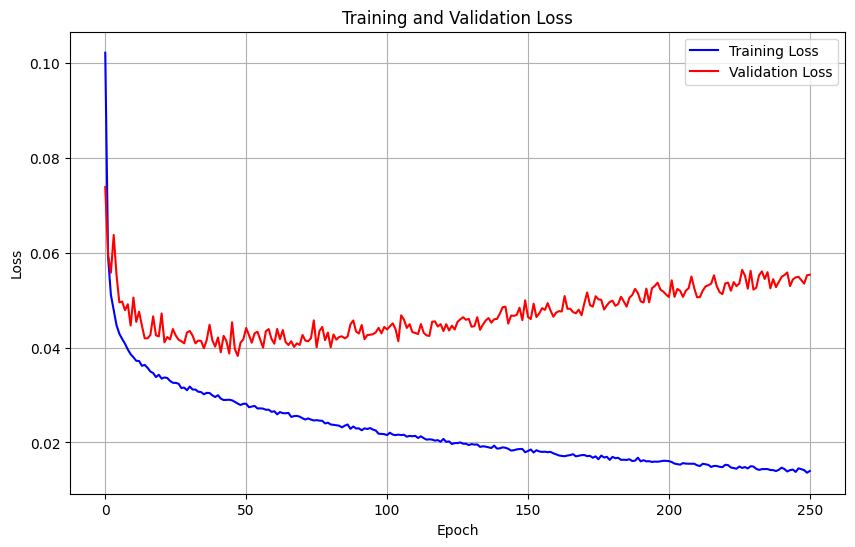

In [ ]:
import matplotlib.pyplot as plt

# Unpack the tuples into lists for plotting
train_loss_values, train_epochs = zip(*[(loss.item(), epoch) for loss, epoch in train_losses])
valid_loss_values, valid_epochs = zip(*[(loss.item(), epoch) for loss, epoch in valid_losses])

# Plotting
plt.figure(figsize=(10, 6))  # Set the figure size for better readability
plt.plot(train_epochs, train_loss_values, label='Training Loss', color='blue')
plt.plot(valid_epochs, valid_loss_values, label='Validation Loss', color='red')

# Adding title and labels
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()  # Show legend to differentiate between training and validation loss

# Show grid for easier visualization
plt.grid(True)

# Display the plot
plt.show()

**Your Analysis Here -**
I used the 150th epoch checkpoint to rollout the policy as it obtained the max success rate of 0.46 over 50 rollouts. The training and validation curves are similar to any other supervised problem, with training loss continuously reducing across epochs while validation loss reducing and increasing after a few epochs. However, these curves do not correlate with task success rates as we obtain optimal success rate at 150 epoch, where both losses are not the lowest. Hence, it was not possible to predict which epoch corresponded to the best performance without policy rollout. This shows that loss is not a good indicator for success rate.

### RNN (10 points)

For the MLP, the state that we are passing into the model is actionally quite limited.  The model can only see the current position of the end effect and the object.  How might we be able to deal with this partial observability?  One possible solution is adding velocity, acceleration, jerk, etc. to the state.  Another solution is passing in a number of previous observations at once.  While both of these methods could work (and may be worth trying during your experiments), with increasingly complex inputs the model becomes computationally expensive, requires more demonstrations, and runs the risk of focusing on spurrious correlations in the data.  

In this section, we will tackle the problem of partial observability by training a network that retains a memory of its past experiences, a Recurrent Neural Network (RNN).  The hidden state of the RNN contains information about what happened in previous timesteps.  The hope is that these learned parameters allow the model to infer some unobserved but relavent aspects of the data, such as velocity or motion patterns.  


We will now reload the dataset with a sequence length of 10.  You can change this sequence length in your experiments, but for now please use 10.

In [ ]:
from helper import load_data_for_training
# For experiments, it is probably best to just alter these parameters
obs_keys = ["object", "robot0_eef_pos", "robot0_eef_quat", "robot0_gripper_qpos"]
seq_len = 10
batch_size = 100
train_loader, valid_loader = load_data_for_training(
    dataset_path=dataset_path,
    obs_keys=obs_keys,
    seq_len=seq_len,
    batch_size=batch_size
)

SequenceDataset: loading dataset into memory...
100%|██████████| 180/180 [00:00<00:00, 500.08it/s]
SequenceDataset: caching get_item calls...
100%|██████████| 27165/27165 [00:01<00:00, 19874.72it/s]
SequenceDataset: loading dataset into memory...
100%|██████████| 20/20 [00:00<00:00, 408.86it/s]
SequenceDataset: caching get_item calls...
100%|██████████| 2989/2989 [00:00<00:00, 20992.73it/s]
batch keys: dict_keys(['actions', 'obs'])
observation shapes: 
object shape: torch.Size([100, 10, 14])
robot0_eef_pos shape: torch.Size([100, 10, 3])
robot0_eef_quat shape: torch.Size([100, 10, 4])
robot0_gripper_qpos shape: torch.Size([100, 10, 2])
action shape: torch.Size([100, 10, 7])


Below you will implement the RNN, here are some guidlines:
* Use nn.LSTM and a fully connected output layer
* Inilitalize hidden state to zeros
* When generating actions, keep track of the hidden state and re-initialize after self.hidden_state_horizon action steps

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import robomimic.utils.tensor_utils as TensorUtils

class DLM_RNN(nn.Module):
  def __init__(
      self,
      input_dim,
      hidden_dim,
      num_layers,
      output_dim,
      obs_keys,
      rnn_horizon
    ):
    """
    Args:
    - input_dim (int): dimension of input obs
    - hidden_dim (int): dimension of hidden state
    - num_layers (int): number of hidden layers
    - output_dim (int): dimension of output action
    - obs_keys (list of str): keys of obs modalities
    - rnn_horizon (int): how many steps to run the RNN before resetting the hidden state
    """
    super(DLM_RNN, self).__init__()
    self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    self.obs_keys = obs_keys
    self.hidden_size = hidden_dim
    self.num_layers = num_layers
    self.hidden_state = None
    self.hidden_state_horizon = rnn_horizon
    self.hidden_state_counter = 0
    ############################################
    # Define the model architecture here       #
    # 1. Initialize LSTM                       #
    self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, device=self.device, batch_first=True)

    # 2. Initialize fully connect output layer #
    self.fc = nn.Linear(hidden_dim, output_dim)

    # 3. Initializer optimizer (same as MLP)   #
    self.optimizer = optim.Adam(self.parameters(), lr=0.0001)
    ############################################

    ##########################################
    # End of code                            #
    ##########################################
    self.to(self.device)
    # This is just for saving the model, don't use this parameter
    self.epoch = 0

  def train_on_batch(self, batch, validate):
    """
    Args:
    - batch (dict): batch of data batch['obs'].shape = (B, T, Obs_dim)
                    and batch['actions'].shape = (B, T, Action_dim)
    - validate (bool): whether batch is for validation

    Returns:
    - loss_val (float): value of loss
    """
    loss_val = None
    ######################################################
    # Define the training loop here                      #
    # 1. Pass obs (and hidden state) through LSTM        #
    # 2. Predict actions using fully connected layer     #
    # 3. Compute MSELoss (for all actions)               #
    # 4. Backprop if not validate                        #
    # Reset hidden state if needed

    obs = batch['obs'].to(self.device)
    actions = batch['actions'].to(self.device)

    if validate:
      with torch.no_grad():
        output, _ = self.lstm(obs, self.hidden_state)
        output = self.fc(output)
        mse_loss = nn.MSELoss()(output, actions)
        self.hidden_state_counter += 1

        if self.hidden_state_counter >= self.hidden_state_horizon:
          self.initialize_hidden_state(actions.shape[0])
          self.reset()
    else:
      output, _ = self.lstm(obs, self.hidden_state)
      output = self.fc(output)
      self.hidden_state_counter += 1

      if self.hidden_state_counter >= self.hidden_state_horizon:
        self.initialize_hidden_state(actions.shape[0])
        self.reset()

      mse_loss = nn.MSELoss()(output, actions)
      self.optimizer.zero_grad()
      mse_loss.backward()
      self.optimizer.step()

    ######################################################

    ######################################
    # End of code                        #
    ######################################
    return mse_loss

  def initialize_hidden_state(self, batch_size):
    """
    Args:
    - batch_size (int): size of batch
    Returns:
    - (h_0, c_0) : initial hidden state and cell state for LSTM
    """
    h_0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(self.device)
    c_0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(self.device)
    return h_0, c_0

  def get_action(self, obs):
    """
    Args:
    - obs (dict): dictionary of observations of shape (B, 1, Obs_dim)
    Returns:
    - action (torch.Tensor): action of shape (B, 1, Action_dim)
    """
    action = None
    ##############################################################
    # Implement logic for action prediction                      #
    # 1. Hidden state should be re-initialized after             #
    #    every self.hidden_state_horizon steps                   #
    # 2. Pass obs through LSTM (along with previus hidden state) #
    # 3. Then use fully connected layer to predict action        #
    # Note: use torch.no_grad()                                  #

    obs = obs.to(self.device)
    with torch.no_grad():
        output, self.hidden_state = self.lstm(obs, self.hidden_state)
        action = self.fc(output)
        # mse_loss = nn.MSELoss()(output, actions)
        self.hidden_state_counter += 1

        if self.hidden_state_counter >= self.hidden_state_horizon:
          self.initialize_hidden_state(actions.shape[0])
          self.reset()
    ##############################################################

    ##############################################################
    # End of code                                                #
    ##############################################################
    return action

  def reset(self):
    # Reset hidden state and hidden state counter
    self.hidden_state = None
    self.hidden_state_counter = 0
    return

  def save(self, path):
    torch.save(self.state_dict(), path)

  def load(self, path):
    #get epoch from end of path
    self.epoch = int(path.split("_")[-1].split(".")[0])
    self.load_state_dict(torch.load(path))


  def set_eval(self):
    self.eval()


Create the model and train.  Most of the challenge with this model is correctly handeling the hidden state.  

In [ ]:
# input_dim = 23 (observation dims) and output_dim = 7 (actions= dim) are calculated in the first section
# remember, input_dim = end_effector_pos_dim + end_effector_quat_dim + gripper_qpos_dim + object_dim

# you can modify these parameters if you want, but tuning shouldn't be necessary
hidden_dim = 400
num_layers = 2
# make sure rnn_horizon is same as dataloader sequence length
rnn_horizon = 10

print(input_dim, output_dim)
model = DLM_RNN(input_dim = input_dim, hidden_dim = hidden_dim, num_layers = num_layers, output_dim = output_dim, obs_keys = obs_keys, rnn_horizon = rnn_horizon)

23 7


In [ ]:
from helper import train

# model epochs saved to save_path/epoch_x.pth where x is every 50 epochs
save_path = os.path.join(path_to_dlm, "trainings/rnn")
if not os.path.exists(save_path):
  os.makedirs(save_path)

Now it is time to train the model, you should be able to achieve the target success rate after ~500 training epochs (20 min).  When debugging feel free to train for less epochs.

**Target Success Rate: 70%**

In [ ]:
from helper import train

num_epochs = 501
train_losses, valid_losses = train(
                                  model,
                                  train_loader,
                                  valid_loader,
                                  num_epochs=num_epochs,
                                  save_path=save_path
                                )

Epoch: 0 Train Loss: 0.16843190789222717 Valid Loss: 0.1321154236793518
Epoch: 10 Train Loss: 0.057024989277124405 Valid Loss: 0.06067629158496857
Epoch: 20 Train Loss: 0.048022136092185974 Valid Loss: 0.05474803224205971
Epoch: 30 Train Loss: 0.04352758079767227 Valid Loss: 0.051546432077884674
Epoch: 40 Train Loss: 0.040417201817035675 Valid Loss: 0.05389704927802086
Epoch: 50 Train Loss: 0.03873945027589798 Valid Loss: 0.048486385494470596
Epoch: 60 Train Loss: 0.03681502118706703 Valid Loss: 0.04686560481786728
Epoch: 70 Train Loss: 0.0351715087890625 Valid Loss: 0.04342605173587799
Epoch: 80 Train Loss: 0.034158963710069656 Valid Loss: 0.042834293097257614
Epoch: 90 Train Loss: 0.032819151878356934 Valid Loss: 0.04130598157644272
Epoch: 100 Train Loss: 0.031458187848329544 Valid Loss: 0.04125247150659561
Epoch: 110 Train Loss: 0.030532125383615494 Valid Loss: 0.042657386511564255
Epoch: 120 Train Loss: 0.029106605798006058 Valid Loss: 0.04318145662546158
Epoch: 130 Train Loss: 0.0

In [ ]:
# Load saved model if you have checkpoints from previous training runs
model.load(os.path.join(save_path, "epoch_400.pth"))

As mentioned before, it will take quite a while to run the rollout loop, so start by visualizing one or two rollouts.  Does the robots actions look reasonable?  Or is it bouncing around wildly?  Remember you have visualizations of the original demonstrations earlier in this notebook if you want to remember the behavior we are trying to imitate.

In [ ]:
from helper import rollout
import imageio

# create a video writer
video_path = "rollout.mp4"
video_writer = imageio.get_writer(video_path, fps=20)

# Feel free to change while debugging
num_rollouts = 2
success_rate = rollout(model,
                      dataset_path,
                      horizon = 400,
                      video_writer = video_writer,
                      obs_keys = obs_keys,
                      num_rollouts = num_rollouts)
print("Success rate over {} rollouts: {}".format(num_rollouts, success_rate))

video_writer.close()

Created environment with name NutAssemblySquare
Action size is 7
Success rate over 2 rollouts: 0.5


Success rates OVER 2 rollouts
500 epoch: 0.5
450 epoch: 0.0
400 epoch: 0.5
350 epoch: 0.5
300 epoch: 0.5
250 epoch: 0.0

over 50 rollouts

250:
300:
350:
400:
450:
500:

In [ ]:
from IPython.display import Video
Video(video_path, embed=True)

Once you are confident that your model is reasonable, then you can take the time to run the full 50 rollouts.

(10 min)

**Do not delete the final output of this cell! We need to see your success rate to score you correctly**

In [ ]:
from helper import rollout
import imageio

num_rollouts = 50
success_rate = rollout(model,
                      dataset_path,
                      horizon = 400,
                      video_writer = None,
                      obs_keys = obs_keys,
                      num_rollouts = num_rollouts)
print("Success rate over {} rollouts: {}".format(num_rollouts, success_rate))

Created environment with name NutAssemblySquare
Action size is 7
Success rate over 50 rollouts: 0.84


## TODO: Plot Training and Validation Loss
Additionally, indicate the checkpoint epoch you used to generate the success rate above.  Write 2/3 sentences reflecting on your takeaways from this process.  If you have time, try loading some of the earlier saved checkpoints and plotting the success rate curve as well (it is okay if you don't have time for this).



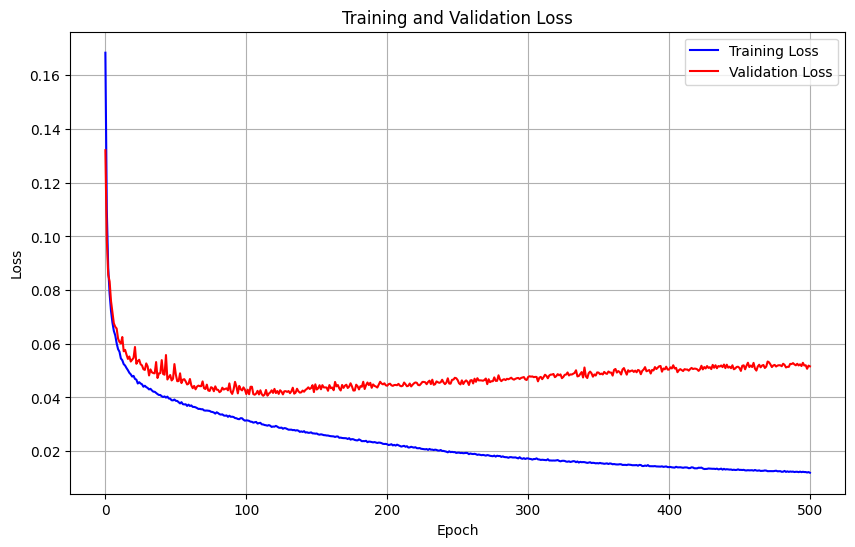

In [ ]:
import matplotlib.pyplot as plt

# Unpack the tuples into lists for plotting
train_loss_values, train_epochs = zip(*[(loss.item(), epoch) for loss, epoch in train_losses])
valid_loss_values, valid_epochs = zip(*[(loss.item(), epoch) for loss, epoch in valid_losses])

# Plotting
plt.figure(figsize=(10, 6))  # Set the figure size for better readability
plt.plot(train_epochs, train_loss_values, label='Training Loss', color='blue')
plt.plot(valid_epochs, valid_loss_values, label='Validation Loss', color='red')

# Adding title and labels
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()  # Show legend to differentiate between training and validation loss

# Show grid for easier visualization
plt.grid(True)

# Display the plot
plt.show()

Created environment with name NutAssemblySquare
Action size is 7
Created environment with name NutAssemblySquare
Action size is 7
Created environment with name NutAssemblySquare
Action size is 7
Created environment with name NutAssemblySquare
Action size is 7
Created environment with name NutAssemblySquare
Action size is 7
Created environment with name NutAssemblySquare
Action size is 7
Created environment with name NutAssemblySquare
Action size is 7
Created environment with name NutAssemblySquare
Action size is 7
Created environment with name NutAssemblySquare
Action size is 7
Created environment with name NutAssemblySquare
Action size is 7
Created environment with name NutAssemblySquare
Action size is 7


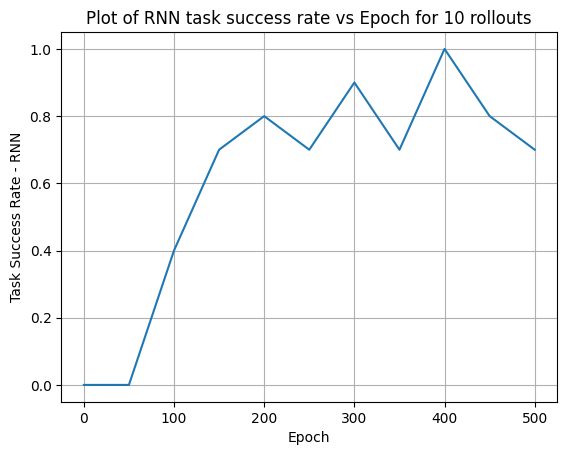

In [ ]:
task_success_rate = []
rollouts = 10
per_50_epoch = 11
epochs = []
for i in range(per_50_epoch):
  model.load(os.path.join(save_path, "epoch_{}.pth".format(i*50)))
  task_success_rate.append(rollout(model,
                      dataset_path,
                      horizon = 400,
                      video_writer = None,
                      obs_keys = obs_keys,
                      num_rollouts = rollouts))
  epochs.append(i*50)
plt.plot(epochs, task_success_rate)
plt.xlabel('Epoch')
plt.ylabel('Task Success Rate - RNN')
plt.title('Plot of RNN task success rate vs Epoch for 10 rollouts')
plt.grid(True)
plt.show()

**Your Analysis Here -**
I used 400th epoch to obtain a success rate of 0.84 or **84%** over 50 rollouts. Incorporating history/previous observations using RNN results in improved performance with smoother trajectories aligning with what we hypothesized. \


*   There is **significant improvement in performance** in terms of task success rate by **incorporating prior timestep observations.**
*  Similar as MLP, **training and validation loss curves do not correlate with success rate**. Training loss reduces continuously across epochs whereas validation loss initially reduces and then begins to increase due to overfitting. However, neither of this help in determining the best checkpoint for task success rate.
*   I plotted the graph of task success rate vs. epochs as shown above for 10 policy rollouts. We can observe that the model's performance quickly increases from the 50th epoch onwards. With minor drops in between, the model then achieves its peak performance at around 400th epoch and then it begins to overfit with performance continuously decreasing beyond 400 epochs.







### Diffusion Policy (10 points) **Extra Credit**

Now you will be implementing action prediction with a Diffusion Model.  Diffusion Models are an extremely popular class of generative models, especially because of their ability to represent multimodal distributions.  For this model your noise will be the shape of the actions that you want to predict and your conditioning information will be the observations.  If you need a refresher on Diffusion Models there are a lot of good resources online, but here are the papers that you are expected to understand to complete this part of the assignment.  You will have a hard time completing this assignment if you have never read these papers:

https://arxiv.org/pdf/2006.11239.pdf (Original Diffusion Model Paper)

https://arxiv.org/pdf/2303.04137.pdf (Diffusion Policy, the paper this implementation is based on)

In [ ]:
%%capture
!pip install diffusers

In [ ]:
from helper import load_data_for_training
# For experiments, it is probably best to just alter these parameters
obs_keys = ["object", "robot0_eef_pos", "robot0_eef_quat", "robot0_gripper_qpos"]
seq_len = 16
batch_size = 100
train_loader, valid_loader = load_data_for_training(
    dataset_path=dataset_path,
    obs_keys=obs_keys,
    seq_len=seq_len,
    batch_size=batch_size,
    frame_stack = 1,
)

SequenceDataset: loading dataset into memory...
100%|██████████| 180/180 [00:00<00:00, 451.50it/s]
SequenceDataset: caching get_item calls...
100%|██████████| 27165/27165 [00:01<00:00, 18918.11it/s]
SequenceDataset: loading dataset into memory...
100%|██████████| 20/20 [00:00<00:00, 370.11it/s]
SequenceDataset: caching get_item calls...
100%|██████████| 2989/2989 [00:00<00:00, 19313.02it/s]
batch keys: dict_keys(['actions', 'obs'])
observation shapes: 
object shape: torch.Size([100, 16, 14])
robot0_eef_pos shape: torch.Size([100, 16, 3])
robot0_eef_quat shape: torch.Size([100, 16, 4])
robot0_gripper_qpos shape: torch.Size([100, 16, 2])
action shape: torch.Size([100, 16, 7])


You will be implementing a very basic version of diffusion policy.  We will use a fixed beta schedule, a constant learning rate, no observation normalization, and delta actions instead of absolute.  For this reason your success rate may not be amazing, but this should give you a sense of how diffusion models can be used for action generation.  Feel free to add any of these components during your experiments if you want to try and get better success rates.  The guidelines for implementing the diffusion model policy are as follows:
* Use DDPMScheduler to add noise to actions during training
* Train noise_pred_net on these noised actions
* Use noise_pred_net to predict the amount of noise to remove at each timestep during inference
* Use DDPMScheduler to remove noise during inference
* You should be using 0 mean, 1 var gaussian noise (torch.randn)



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import robomimic.utils.tensor_utils as TensorUtils
from copy import deepcopy

# do not import any additional diffusion model packages for this part of the assignment
# you are free to implement any packages you want for the experiments at the end of the assignment
from diffusers import DDPMScheduler
from helperModels import ConditionalUnet1D
from diffusers.training_utils import EMAModel



class DLM_Diffusion(nn.Module):
  def __init__(
      self,
      output_dim,
      input_dim,
      denoising_steps,
      obs_horizon,
      prediction_horizon,
      action_horizon,
    ):

    super(DLM_Diffusion, self).__init__()
    self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    self.denoising_steps = denoising_steps
    self.output_dim = output_dim
    self.obs_horizon = obs_horizon
    self.prediction_horizon = prediction_horizon
    self.action_horizon = action_horizon
    self.input_dim = input_dim

    ######################################
    # Initialize the noise pred net      #
    # Change the input and cond dims     #
    ######################################
    # Input_dim is action dim
    # global con dim is flattened obs dim
    self.noise_pred_net = ConditionalUnet1D(
      input_dim=self.output_dim,
      global_cond_dim=self.obs_horizon*self.input_dim
    )
    ######################################
    # End of code                        #
    ######################################


    self.scheduler = DDPMScheduler(
        num_train_timesteps=self.denoising_steps,
        # the choise of beta schedule has big impact on performance
        # we found squared cosine works the best
        beta_schedule='squaredcos_cap_v2',
        # clip output to [-1,1] to improve stability
        clip_sample=True,
        # our network predicts noise (instead of denoised action)
        prediction_type='epsilon'
    )

    self.noise_pred_net.to(self.device)
    self.optimizer = optim.Adam(self.noise_pred_net.parameters(), lr=1e-4)
    self.ema = EMAModel(parameters=self.noise_pred_net.parameters(),power=0.75)
    self.ema.to(self.device)
    # This is just for saving the model, don't use this parameter
    self.epoch = 0



  def train_on_batch(self, batch, validate):
    """
    Args:
    - batch (dict): batch of data batch['obs'].shape = (B, T, Obs_dim) and batch['actions'].shape = (B, T, Action_dim)
    - validate (bool): whether batch is for validation
    Returns:
    - loss_val (float): value of loss
    """
    loss_val = None
    ######################################
    # Define the training loop here      #
    ######################################
    # make sure to flatten obs (B, T, D) -> (B, --)

    if validate:
      with torch.no_grad():
        obs = batch['obs']
        actions = batch['actions']

        noise = torch.randn((actions.shape[0], self.prediction_horizon, self.output_dim)).to(self.device)

        time_steps = torch.randint(0, self.denoising_steps, (obs.shape[0],)).long().to(self.device)
        noised_actions = self.scheduler.add_noise(actions, noise, time_steps)

        global_cond = obs[:, :self.obs_horizon, :].reshape(obs.shape[0], -1)

        predicted_noise = self.noise_pred_net(sample=noised_actions, timestep=time_steps, global_cond=global_cond)

        loss_val = nn.MSELoss()(noise, predicted_noise)
    else:
        obs = batch['obs']
        actions = batch['actions']

        noise = torch.randn((actions.shape[0], self.prediction_horizon, self.output_dim)).to(self.device)

        time_steps = torch.randint(0, self.denoising_steps, (obs.shape[0],)).long().to(self.device)
        noised_actions = self.scheduler.add_noise(actions, noise, time_steps)

        '''
        print(obs.shape, self.obs_horizon)
        obs_horizon = obs[:, :self.obs_horizon, :]
        print(obs_horizon.shape)
        global_cond = obs_horizon.reshape(obs.shape[0], -1)
        print(global_cond.shape)
        '''

        global_cond = obs[:, :self.obs_horizon, :].reshape(obs.shape[0], -1)

        predicted_noise = self.noise_pred_net(sample=noised_actions, timestep=time_steps, global_cond=global_cond)

        loss_val = nn.MSELoss()(noise, predicted_noise)
        self.optimizer.zero_grad()
        loss_val.backward()
        self.optimizer.step()
        self.ema.step(self.noise_pred_net.parameters())
    ######################################
    # End of code                        #
    ######################################
    return loss_val

  def get_action(self, obs):
    """
    Args:
    - obs (dict): dictionary of observations of shape (B, prediction_horizon, Obs_dim)
    Returns:
    - actions (np.ndarray): action of shape (B, action_horizon, Action_dim)
    """
    # obs are (B, T, D) - make sure to flatten obs
    # also, remember obs_horizon is not the same as prediction_horizon
    original_params = deepcopy(self.noise_pred_net.state_dict())
    self.ema.copy_to(self.noise_pred_net.parameters())
    self.noise_pred_net.eval()
    actions = None

    ######################################################
    # Generate an action sample from the diffusion model #
    ######################################################
    with torch.no_grad():
      noised_actions = torch.randn((obs.shape[0], self.prediction_horizon, self.output_dim)).to(self.device)
      global_obs_cond = obs[:, :self.obs_horizon, :].reshape(obs.shape[0], -1)

      self.scheduler.set_timesteps(self.denoising_steps)
      timesteps = self.scheduler.timesteps

      for i in timesteps:
        predicted_noise = self.noise_pred_net(sample=noised_actions, timestep=i, global_cond=global_obs_cond)
        noised_actions = self.scheduler.step(model_output=predicted_noise, timestep=i, sample=noised_actions).prev_sample


      actions = noised_actions[:, self.obs_horizon-1:self.obs_horizon-1+self.action_horizon,:]
    ####################################################################################
    #                                 END OF YOUR CODE                                 #
    ####################################################################################

    # restore original params
    self.noise_pred_net.load_state_dict(original_params)

    return actions

  def reset(self):
    return

  def save(self, path):
    torch.save(self.state_dict(), path)
    # save the ema model, put ema before the .pth
    torch.save(self.ema.state_dict(), path.replace(".pth", "ema.pth"))

  def load(self, path):
    #get epoch from end of path
    self.epoch = int(path.split("_")[-1].split(".")[0])
    self.load_state_dict(torch.load(path))
    self.ema.load_state_dict(torch.load(path.replace(".pth", "ema.pth")))

  def set_eval(self):
    self.eval()

Create the mode and train.  It is really important that you understand the diffusion model training and inference process, if you are having troubles please review the basics of diffusion models.

In [ ]:
from helper import train

# model epochs saved to save_path/epoch_x.pth where x is every 50 epochs
# save_path = os.path.join(path_to_dlm, "trainings/diffusion")
save_path = os.path.join(path_to_dlm, "trainings/dummy")
if not os.path.exists(save_path):
  os.makedirs(save_path)

In [ ]:
# input_dim = 23 (observation dims) and output_dim = 7 (actions= dim) are calculated in the first section
# remember, input_dim = end_effector_pos_dim + end_effector_quat_dim + gripper_qpos_dim + object_dim

input_dim = 23
output_dim = 7
denoising_steps = 100
prediction_horizon = 16
action_horizon = 8
obs_horizon = 2

model = DLM_Diffusion(
    output_dim = output_dim,
    input_dim = input_dim,
    denoising_steps=denoising_steps,
    prediction_horizon=prediction_horizon,
    action_horizon=action_horizon,
    obs_horizon = obs_horizon
    )

number of parameters: 6.587828e+07


In [ ]:
# Load saved model if you have checkpoints from previous training runs
model.load(os.path.join(save_path, "epoch_50.pth"))

Now it is time to train the model, you should be able to achieve the target success rate after ~50 training epochs. (1 hr)

**Target Success Rate: 50%**

In [ ]:
from helper import train

num_epochs = 51
training_losses, validation_losses = train(model, train_loader, valid_loader, num_epochs=num_epochs, save_path = save_path)

/usr/local/lib/python3.10/dist-packages/transformers/deepspeed.py:23: FutureWarning: transformers.deepspeed module is deprecated and will be removed in a future version. Please import deepspeed modules directly from transformers.integrations
  warnings.warn(


Epoch: 0 Train Loss: 0.2678750455379486 Valid Loss: 0.09982099384069443
Epoch: 10 Train Loss: 0.05504714697599411 Valid Loss: 0.05707657337188721
Epoch: 20 Train Loss: 0.050423115491867065 Valid Loss: 0.0530426949262619
Epoch: 30 Train Loss: 0.04812370240688324 Valid Loss: 0.05302571505308151
Epoch: 40 Train Loss: 0.044469110667705536 Valid Loss: 0.05371132865548134
Epoch: 50 Train Loss: 0.04124128818511963 Valid Loss: 0.05633099749684334


This will take a really really long time to run (even longer than the last ones).  Please keep this in mind when doing your experiments.  We do not recommend doing experiments that will increase you inference time, maybe forcus on experiments that lower inference time.  First lets debug by visualizing a few rollouts.

In [ ]:
from helper import rollout
import imageio

# create a video writer
video_path = "rollout.mp4"
video_writer = imageio.get_writer(video_path, fps=20)

num_rollouts = 2
success_rate = rollout(model,
                      dataset_path,
                      horizon = 400,
                      video_writer = video_writer,
                      obs_keys = obs_keys,
                      num_rollouts = num_rollouts,
                      obs_len = 2)
print("Success rate over {} rollouts: {}".format(num_rollouts, success_rate))

video_writer.close()

Created environment with name NutAssemblySquare
Action size is 7
Success rate over 2 rollouts: 0.5


In [ ]:
from IPython.display import Video
Video(video_path, embed=True)

Once you are confident that your model is reasonable, then you can take the time to run the full 50 rollouts.

(35 min)

**Do not delete the final output of this cell! We need to see your success rate to score you correctly**

In [ ]:
from helper import rollout
import imageio

num_rollouts = 50
success_rate = rollout(model,
                      dataset_path,
                      horizon = 400,
                      video_writer = None,
                      obs_keys = obs_keys,
                      num_rollouts = num_rollouts,
                      obs_len = 2)
print("Success rate over {} rollouts: {}".format(num_rollouts, success_rate))

Created environment with name NutAssemblySquare
Action size is 7
Success rate over 50 rollouts: 0.74


## TODO: Plot Training and Validation Loss
Additionally, indicate the checkpoint epoch you used to generate the success rate above.  Write 2/3 sentences reflecting on your takeaways from this process.  How was the training different from the other models?  Why can you use such an early checkpoint?

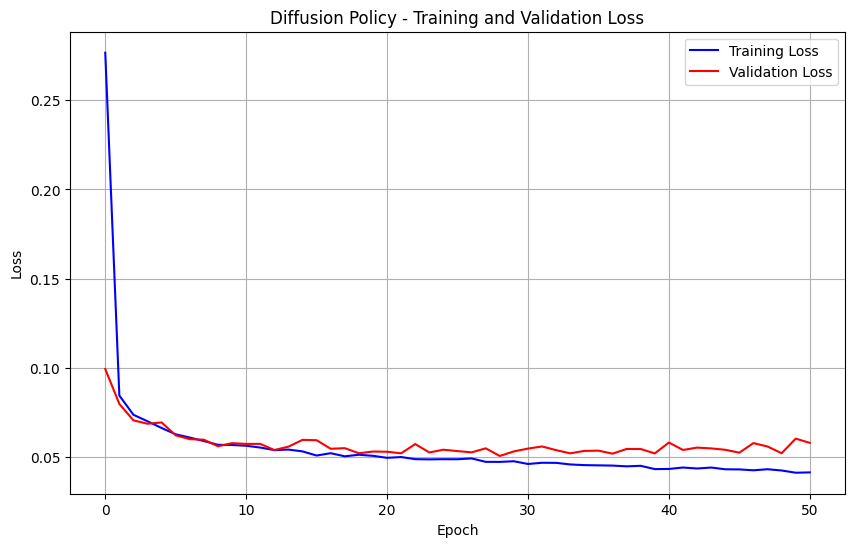

In [ ]:
import matplotlib.pyplot as plt

# Unpack the tuples into lists for plotting
train_loss_values, train_epochs = zip(*[(loss.item(), epoch) for loss, epoch in training_losses])
valid_loss_values, valid_epochs = zip(*[(loss.item(), epoch) for loss, epoch in validation_losses])

# Plotting
plt.figure(figsize=(10, 6))  # Set the figure size for better readability
plt.plot(train_epochs, train_loss_values, label='Training Loss', color='blue')
plt.plot(valid_epochs, valid_loss_values, label='Validation Loss', color='red')

# Adding title and labels
plt.title('Diffusion Policy - Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()  # Show legend to differentiate between training and validation loss

# Show grid for easier visualization
plt.grid(True)

# Display the plot
plt.show()

**Your Analysis Here -**
I used 50th epoch for obtaining the success rate of 0.74 over 50 rollouts. The convergence in case of Diffusion Policy was quicker at 50th epoch compared to previous approaches as they are simpler in terms of complexity and have regualarizing effect due to smoothing and information spread across the diffusion chain. These leads to smoother loss optimization and stable training.

*   Training and validation loss continuously reduce across epochs. However they **do not correlate to task success rates** similar to the previous approaches.
*   One of the things that is different here than previous approaches is that the validation loss does not vary/reduce smoothly with the training loss and does fluctuate a lot.



# Experiments (30 points)

Okay now it is time to do some experiments with the models you implemented.  There are 4 different variables that we want you to investigate.  For each section you need to come up with a hypothesis, run an experiment to test that hypothesis, and then analyze whether or not your hypothesis was proved or disproved.  These do not need to be novel discoveries, we just want you to see how common dataset characteristics are impacted by different aspects of these models.  For each section below the points breakdown is as follows:

* (2pt) **Hypothesis** - For each dataset characteristic, formulate a hypothesis that explores the interaction between this characteristic and a specific variable or parameter in one of your implemented models. Your hypothesis should reflect how changes in the model parameter might influence the performance or behavior of the model with respect to the given dataset characteristic.
* (4pt) **Experiment** -  Describe the experiment you ran and include at least one figure.
* (4pt) **Analysis** - Explain whether or not your hypothesis was proved or disproved.  What would be an interesting next experiment after seeing these results?


**To get full credit**, you must experiment with the parameters off all implemented models at least once (except the diffusion model as this is extra credit).  For example, you can't just modify the parameters of the MLP for all experiments.  Failure to do so will results in -5 points.

This is the bulk of the homework assignment! So have a good time with it, make pretty graphs, and hopefully discover something interesting.

## **Task Difficulty (10 PT)**
Lift (easy) vs. Square (medium) vs. Tool Hang (Hard)

Example Hypothesis: If I increase the depth of the MLP, I will see increased performance on harder tasks.

The robomimic demonstration datasets contain a number of different tasks with varying levels of difficulty.  Below we provide download links to three such tasks.  You can load them into the data loaders from previous sections as you perform your experiments.  

In [ ]:
# Download demonstration dataset
import robomimic.utils.file_utils as FileUtils

# the dataset registry can be found at robomimic/__init__.py
from robomimic import DATASET_REGISTRY

# set download folder for EASY task
lift_folder = os.path.join(path_to_dlm, 'datasets/lift/ph')
os.makedirs(lift_folder, exist_ok=True)

#download the dataset
task = "lift"
dataset_type = "ph"
hdf5_type = "low_dim"
FileUtils.download_url(
    url=DATASET_REGISTRY[task][dataset_type][hdf5_type]["url"],
    download_dir=lift_folder,
)

# enforce that the dataset exists
lift_path = os.path.join(lift_folder, "low_dim_v141.hdf5")
assert os.path.exists(lift_path)

# set download folder for MEDIUM task
square_folder = os.path.join(path_to_dlm, 'datasets/square/ph')
os.makedirs(square_folder, exist_ok=True)

#download the dataset
task = "square"
dataset_type = "ph"
hdf5_type = "low_dim"
FileUtils.download_url(
    url=DATASET_REGISTRY[task][dataset_type][hdf5_type]["url"],
    download_dir=square_folder,
)

# enforce that the dataset exists
square_path = os.path.join(square_folder, "low_dim_v141.hdf5")
assert os.path.exists(square_path)

# set download folder for HARD task
tool_hang_folder = os.path.join(path_to_dlm, 'datasets/tool_hang/ph')
os.makedirs(tool_hang_folder, exist_ok=True)

#download the dataset
task = "tool_hang"
dataset_type = "ph"
hdf5_type = "low_dim"
FileUtils.download_url(
    url=DATASET_REGISTRY[task][dataset_type][hdf5_type]["url"],
    download_dir=tool_hang_folder,
)

# enforce that the dataset exists
tool_hang_path = os.path.join(tool_hang_folder, "low_dim_v141.hdf5")
assert os.path.exists(tool_hang_path)

y


low_dim_v141.hdf5: 21.7MB [00:07, 2.78MB/s]                            


y


low_dim_v141.hdf5: 53.0MB [00:27, 1.91MB/s]                            


y


low_dim_v141.hdf5: 205MB [01:16, 2.68MB/s]                           


### TODO:

**You can add however many code blocks here, but leave the most essential ones upon submission to prove your work.**


#### Square task - Model size [1024], [1024, 1024], [1024, 1024, 1024]

In [ ]:
### 1. square task - size [1024]
# Load in the data for training
from helper import load_data_for_training
obs_keys = ["object", "robot0_eef_pos", "robot0_eef_quat", "robot0_gripper_qpos"]
seq_len = 1
batch_size = 100
train_loader, valid_loader = load_data_for_training(
    dataset_path=square_path,
    obs_keys=obs_keys,
    seq_len=seq_len,
    batch_size=batch_size
)

input_dim = 23
output_dim = 7
hidden_dims = [1024]
square_small_model = DLMMLP(input_dim=input_dim, hidden_dims=hidden_dims, output_dim=output_dim, obs_keys = obs_keys)

from helper import train

# model epochs saved to save_path/epoch_x.pth where x is every 50 epochs
save_path = os.path.join(path_to_dlm, "trainings/task_difficulty_square_small_mlp")
if not os.path.exists(save_path):
  os.makedirs(save_path)

num_epochs = 251


# train_losses and valid losses are lists of (loss, epoch) tupples
# train_losses, valid_losses = train(square_small_model, train_loader, valid_loader, num_epochs=num_epochs, save_path=save_path)


# Load saved model if you have checkpoints from previous training runs
save_path = os.path.join(path_to_dlm, "trainings/task_difficulty_square_small_mlp")
square_small_model.load(os.path.join(save_path, "epoch_150.pth"))

from helper import rollout
import imageio

# Do not change num_rollouts
num_rollouts = 50

# video write is off to speed up rollouts slightly
success_rate = rollout(square_small_model,
                      square_path,
                      horizon = 400,
                      video_writer = None,
                      obs_keys = obs_keys,
                      num_rollouts = num_rollouts)
print("Model size [1024] - Success rate over {} rollouts: {} on NutAssemblySquare task".format(num_rollouts, success_rate))





### 2. Square task - [1024, 1024]
# Load in the data for training
input_dim = 23
output_dim = 7
hidden_dims = [1024, 1024]
square_model = DLMMLP(input_dim=input_dim, hidden_dims=hidden_dims, output_dim=output_dim, obs_keys = obs_keys)

from helper import train

# model epochs saved to save_path/epoch_x.pth where x is every 50 epochs
save_path = os.path.join(path_to_dlm, "trainings/task_difficulty_square_mlp")
if not os.path.exists(save_path):
  os.makedirs(save_path)

num_epochs = 251


# train_losses and valid losses are lists of (loss, epoch) tupples
# train_losses, valid_losses = train(square_model, train_loader, valid_loader, num_epochs=num_epochs, save_path=save_path)


# Load saved model if you have checkpoints from previous training runs
save_path = os.path.join(path_to_dlm, "trainings/task_difficulty_square_mlp")
square_model.load(os.path.join(save_path, "epoch_150.pth"))

from helper import rollout
import imageio

# Do not change num_rollouts
num_rollouts = 50

# video write is off to speed up rollouts slightly
success_rate = rollout(square_model,
                      square_path,
                      horizon = 400,
                      video_writer = None,
                      obs_keys = obs_keys,
                      num_rollouts = num_rollouts)
print("Model size [1024, 1024] - Success rate over {} rollouts: {} on NutAssemblySquare task".format(num_rollouts, success_rate))





### 3. Square task - [1024, 1024, 1024]
# Load in the data for training
input_dim = 23
output_dim = 7
hidden_dims = [1024, 1024, 1024]
square_large_model = DLMMLP(input_dim=input_dim, hidden_dims=hidden_dims, output_dim=output_dim, obs_keys = obs_keys)

from helper import train

# model epochs saved to save_path/epoch_x.pth where x is every 50 epochs
save_path = os.path.join(path_to_dlm, "trainings/task_difficulty_square_large_mlp")
if not os.path.exists(save_path):
  os.makedirs(save_path)

num_epochs = 251

# train_losses and valid losses are lists of (loss, epoch) tupples
# train_losses, valid_losses = train(square_large_model, train_loader, valid_loader, num_epochs=num_epochs, save_path=save_path)


# Load saved model if you have checkpoints from previous training runs
save_path = os.path.join(path_to_dlm, "trainings/task_difficulty_square_large_mlp")
square_large_model.load(os.path.join(save_path, "epoch_150.pth"))

from helper import rollout
import imageio

# Do not change num_rollouts
num_rollouts = 50

# video write is off to speed up rollouts slightly
success_rate = rollout(square_large_model,
                      square_path,
                      horizon = 400,
                      video_writer = None,
                      obs_keys = obs_keys,
                      num_rollouts = num_rollouts)
print("Model size [1024, 1024, 1024] - Success rate over {} rollouts: {} on NutAssemblySquare task".format(num_rollouts, success_rate))

SequenceDataset: loading dataset into memory...
100%|██████████| 180/180 [00:00<00:00, 407.04it/s]
SequenceDataset: caching get_item calls...
100%|██████████| 27165/27165 [00:01<00:00, 24751.60it/s]
SequenceDataset: loading dataset into memory...
100%|██████████| 20/20 [00:00<00:00, 271.74it/s]
SequenceDataset: caching get_item calls...
100%|██████████| 2989/2989 [00:00<00:00, 21078.43it/s]
batch keys: dict_keys(['actions', 'obs'])
observation shapes: 
object shape: torch.Size([100, 1, 14])
robot0_eef_pos shape: torch.Size([100, 1, 3])
robot0_eef_quat shape: torch.Size([100, 1, 4])
robot0_gripper_qpos shape: torch.Size([100, 1, 2])
action shape: torch.Size([100, 1, 7])
Created environment with name NutAssemblySquare
Action size is 7
Model size [1024] - Success rate over 50 rollouts: 0.46 on NutAssemblySquare task
Created environment with name NutAssemblySquare
Action size is 7
Model size [1024, 1024] - Success rate over 50 rollouts: 0.36 on NutAssemblySquare task
Created environment wi

#### Lift task - Model Size [1024], [1024, 1024], [1024, 1024, 1024]

In [ ]:
### 1. Lift task - size [1024]
# Load in the data for training
from helper import load_data_for_training
obs_keys = ["object", "robot0_eef_pos", "robot0_eef_quat", "robot0_gripper_qpos"]
seq_len = 1
batch_size = 100
train_loader, valid_loader = load_data_for_training(
    dataset_path=lift_path,
    obs_keys=obs_keys,
    seq_len=seq_len,
    batch_size=batch_size
)

input_dim = 19
output_dim = 7
hidden_dims = [1024]
lift_small_model = DLMMLP(input_dim=input_dim, hidden_dims=hidden_dims, output_dim=output_dim, obs_keys = obs_keys)

from helper import train

# model epochs saved to save_path/epoch_x.pth where x is every 50 epochs
save_path = os.path.join(path_to_dlm, "trainings/task_difficulty_lift_small_mlp")
if not os.path.exists(save_path):
  os.makedirs(save_path)

num_epochs = 251

# train_losses and valid losses are lists of (loss, epoch) tupples
# train_losses, valid_losses = train(lift_small_model, train_loader, valid_loader, num_epochs=num_epochs, save_path=save_path)


# Load saved model if you have checkpoints from previous training runs
save_path = os.path.join(path_to_dlm, "trainings/task_difficulty_lift_small_mlp")
lift_small_model.load(os.path.join(save_path, "epoch_150.pth"))

from helper import rollout
import imageio

# Do not change num_rollouts
num_rollouts = 50

# video write is off to speed up rollouts slightly
success_rate = rollout(lift_small_model,
                      lift_path,
                      horizon = 400,
                      video_writer = None,
                      obs_keys = obs_keys,
                      num_rollouts = num_rollouts)
print("Model size [1024] - Success rate over {} rollouts: {} on Lift task".format(num_rollouts, success_rate))





### 2. Lift task - [1024, 1024]
# Load in the data for training
input_dim = 19
output_dim = 7
hidden_dims = [1024, 1024]
lift_model = DLMMLP(input_dim=input_dim, hidden_dims=hidden_dims, output_dim=output_dim, obs_keys = obs_keys)

from helper import train

# model epochs saved to save_path/epoch_x.pth where x is every 50 epochs
save_path = os.path.join(path_to_dlm, "trainings/task_difficulty_lift_mlp")
if not os.path.exists(save_path):
  os.makedirs(save_path)

num_epochs = 251

# train_losses and valid losses are lists of (loss, epoch) tupples
# train_losses, valid_losses = train(lift_model, train_loader, valid_loader, num_epochs=num_epochs, save_path=save_path)


# Load saved model if you have checkpoints from previous training runs
save_path = os.path.join(path_to_dlm, "trainings/task_difficulty_lift_mlp")
lift_model.load(os.path.join(save_path, "epoch_150.pth"))

from helper import rollout
import imageio

# Do not change num_rollouts
num_rollouts = 50

# video write is off to speed up rollouts slightly
success_rate = rollout(lift_model,
                      lift_path,
                      horizon = 400,
                      video_writer = None,
                      obs_keys = obs_keys,
                      num_rollouts = num_rollouts)
print("Model size [1024, 1024] - Success rate over {} rollouts: {} on Lift task".format(num_rollouts, success_rate))





### 3. Lift task - [1024, 1024, 1024]
# Load in the data for training
input_dim = 19
output_dim = 7
hidden_dims = [1024, 1024, 1024]
lift_large_model = DLMMLP(input_dim=input_dim, hidden_dims=hidden_dims, output_dim=output_dim, obs_keys = obs_keys)

from helper import train

# model epochs saved to save_path/epoch_x.pth where x is every 50 epochs
save_path = os.path.join(path_to_dlm, "trainings/task_difficulty_lift_large_mlp")
if not os.path.exists(save_path):
  os.makedirs(save_path)

num_epochs = 251

# train_losses and valid losses are lists of (loss, epoch) tupples
# train_losses, valid_losses = train(lift_large_model, train_loader, valid_loader, num_epochs=num_epochs, save_path=save_path)


# Load saved model if you have checkpoints from previous training runs
save_path = os.path.join(path_to_dlm, "trainings/task_difficulty_lift_large_mlp")
lift_large_model.load(os.path.join(save_path, "epoch_150.pth"))

from helper import rollout
import imageio

# Do not change num_rollouts
num_rollouts = 50

# video write is off to speed up rollouts slightly
success_rate = rollout(lift_large_model,
                      lift_path,
                      horizon = 400,
                      video_writer = None,
                      obs_keys = obs_keys,
                      num_rollouts = num_rollouts)
print("Model size [1024, 1024, 1024] - Success rate over {} rollouts: {} on Lift task".format(num_rollouts, success_rate))

SequenceDataset: loading dataset into memory...
100%|██████████| 180/180 [00:00<00:00, 630.92it/s]
SequenceDataset: caching get_item calls...
100%|██████████| 8640/8640 [00:00<00:00, 23627.45it/s]
SequenceDataset: loading dataset into memory...
100%|██████████| 20/20 [00:00<00:00, 358.84it/s]
SequenceDataset: caching get_item calls...
100%|██████████| 1026/1026 [00:00<00:00, 24544.04it/s]
batch keys: dict_keys(['actions', 'obs'])
observation shapes: 
object shape: torch.Size([100, 1, 10])
robot0_eef_pos shape: torch.Size([100, 1, 3])
robot0_eef_quat shape: torch.Size([100, 1, 4])
robot0_gripper_qpos shape: torch.Size([100, 1, 2])
action shape: torch.Size([100, 1, 7])
Created environment with name Lift
Action size is 7
Model size [1024] - Success rate over 50 rollouts: 0.96 on Lift task
Created environment with name Lift
Action size is 7
Model size [1024, 1024] - Success rate over 50 rollouts: 1.0 on Lift task
Created environment with name Lift
Action size is 7
Model size [1024, 1024, 1

#### Tool hang task - Model size [1024], [1024, 1024], [1024, 1024, 1024]

In [ ]:
### 1. Tool hang task - size [1024]
# Load in the data for training
from helper import load_data_for_training
obs_keys = ["object", "robot0_eef_pos", "robot0_eef_quat", "robot0_gripper_qpos"]
seq_len = 1
batch_size = 100
train_loader, valid_loader = load_data_for_training(
    dataset_path=tool_hang_path,
    obs_keys=obs_keys,
    seq_len=seq_len,
    batch_size=batch_size
)

input_dim = 53
output_dim = 7
hidden_dims = [1024]
tool_hang_small_model = DLMMLP(input_dim=input_dim, hidden_dims=hidden_dims, output_dim=output_dim, obs_keys = obs_keys)

from helper import train

# model epochs saved to save_path/epoch_x.pth where x is every 50 epochs
save_path = os.path.join(path_to_dlm, "trainings/task_difficulty_tool_hang_small_mlp")
if not os.path.exists(save_path):
  os.makedirs(save_path)

num_epochs = 251

# train_losses and valid losses are lists of (loss, epoch) tupples
# train_losses, valid_losses = train(tool_hang_small_model, train_loader, valid_loader, num_epochs=num_epochs, save_path=save_path)


# Load saved model if you have checkpoints from previous training runs
save_path = os.path.join(path_to_dlm, "trainings/task_difficulty_tool_hang_small_mlp")
tool_hang_small_model.load(os.path.join(save_path, "epoch_150.pth"))

from helper import rollout
import imageio

# Do not change num_rollouts
num_rollouts = 50

# video write is off to speed up rollouts slightly
success_rate = rollout(tool_hang_small_model,
                      tool_hang_path,
                      horizon = 800,
                      video_writer = None,
                      obs_keys = obs_keys,
                      num_rollouts = num_rollouts)
print("Model size [1024] - Success rate over {} rollouts: {} on Tool hang task".format(num_rollouts, success_rate))





### 2. Tool hang task - [1024, 1024]
# Load in the data for training
input_dim = 53
output_dim = 7
hidden_dims = [1024, 1024]
tool_hang_model = DLMMLP(input_dim=input_dim, hidden_dims=hidden_dims, output_dim=output_dim, obs_keys = obs_keys)

from helper import train

# model epochs saved to save_path/epoch_x.pth where x is every 50 epochs
save_path = os.path.join(path_to_dlm, "trainings/task_difficulty_tool_hang_mlp")
if not os.path.exists(save_path):
  os.makedirs(save_path)

num_epochs = 251

# train_losses and valid losses are lists of (loss, epoch) tupples
# train_losses, valid_losses = train(tool_hang_model, train_loader, valid_loader, num_epochs=num_epochs, save_path=save_path)


# Load saved model if you have checkpoints from previous training runs
save_path = os.path.join(path_to_dlm, "trainings/task_difficulty_tool_hang_mlp")
tool_hang_model.load(os.path.join(save_path, "epoch_150.pth"))

from helper import rollout
import imageio

# Do not change num_rollouts
num_rollouts = 50

# video write is off to speed up rollouts slightly
success_rate = rollout(tool_hang_model,
                      tool_hang_path,
                      horizon = 800,
                      video_writer = None,
                      obs_keys = obs_keys,
                      num_rollouts = num_rollouts)
print("Model size [1024, 1024] - Success rate over {} rollouts: {} on Tool hang task".format(num_rollouts, success_rate))





### 3. Tool hang task - [1024, 1024, 1024]
# Load in the data for training
input_dim = 53
output_dim = 7
hidden_dims = [1024, 1024, 1024]
tool_hang_large_model = DLMMLP(input_dim=input_dim, hidden_dims=hidden_dims, output_dim=output_dim, obs_keys = obs_keys)

from helper import train

# model epochs saved to save_path/epoch_x.pth where x is every 50 epochs
save_path = os.path.join(path_to_dlm, "trainings/task_difficulty_tool_hang_large_mlp")
if not os.path.exists(save_path):
  os.makedirs(save_path)

num_epochs = 251

# train_losses and valid losses are lists of (loss, epoch) tupples
# train_losses, valid_losses = train(tool_hang_large_model, train_loader, valid_loader, num_epochs=num_epochs, save_path=save_path)

# Load saved model if you have checkpoints from previous training runs
save_path = os.path.join(path_to_dlm, "trainings/task_difficulty_tool_hang_large_mlp")
tool_hang_large_model.load(os.path.join(save_path, "epoch_150.pth"))

from helper import rollout
import imageio

# Do not change num_rollouts
num_rollouts = 50

# video write is off to speed up rollouts slightly
success_rate = rollout(tool_hang_large_model,
                      tool_hang_path,
                      horizon = 800,
                      video_writer = None,
                      obs_keys = obs_keys,
                      num_rollouts = num_rollouts)
print("Model size [1024, 1024, 1024] - Success rate over {} rollouts: {} on Tool hang task".format(num_rollouts, success_rate))

SequenceDataset: loading dataset into memory...
100%|██████████| 180/180 [00:00<00:00, 330.31it/s]
SequenceDataset: caching get_item calls...
100%|██████████| 86336/86336 [00:03<00:00, 23233.65it/s]
SequenceDataset: loading dataset into memory...
100%|██████████| 20/20 [00:00<00:00, 356.50it/s]
SequenceDataset: caching get_item calls...
100%|██████████| 9626/9626 [00:00<00:00, 15437.87it/s]
batch keys: dict_keys(['actions', 'obs'])
observation shapes: 
object shape: torch.Size([100, 1, 44])
robot0_eef_pos shape: torch.Size([100, 1, 3])
robot0_eef_quat shape: torch.Size([100, 1, 4])
robot0_gripper_qpos shape: torch.Size([100, 1, 2])
action shape: torch.Size([100, 1, 7])


[robosuite WARNING] No private macro file found! (macros.py:53)
[robosuite WARNING] It is recommended to use a private macro file (macros.py:54)
[robosuite WARNING] To setup, run: python /content/./robosuite/robosuite/scripts/setup_macros.py (macros.py:55)


Created environment with name ToolHang
Action size is 7
Model size [1024] - Success rate over 50 rollouts: 0.0 on Tool hang task
Created environment with name ToolHang
Action size is 7
Model size [1024, 1024] - Success rate over 50 rollouts: 0.02 on Tool hang task
Created environment with name ToolHang
Action size is 7
Model size [1024, 1024, 1024] - Success rate over 50 rollouts: 0.04 on Tool hang task


**Enter your hypothesis here:** If I increase the depth of MLP, I will see increased performance on harder tasks.

**Enter your experiment here:**

*   Performed experiments on Lift (easy) vs. Square (medium) vs. Tool Hang (hard) with MLP of varying depths - [1024], [1024,1024], [1024,1024,1024]
*   Evaluated task success rate for Lift (easy) vs. Square (medium) vs. Tool Hang (hard) with different depths as above.



****Include figures, brief explanation of the figures. You may use more than one cell****

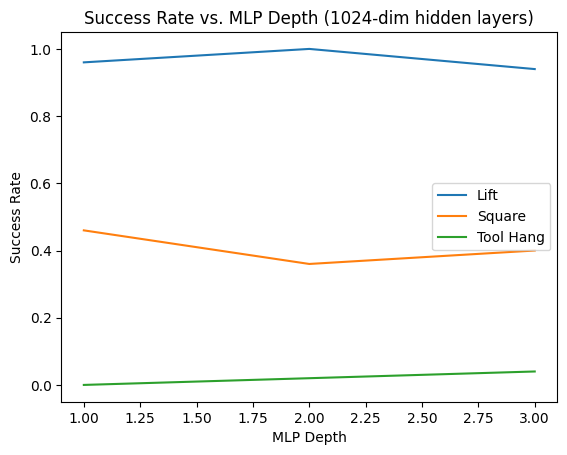

In [ ]:
import matplotlib.pyplot as plt

mlp_depth = [1,2,3]
success_rate_square = [0.46, 0.36, 0.4]
success_rate_lift = [0.96, 1.0, 0.94]
success_rate_tool_hang = [0.0, 0.02, 0.04]

plt.plot(mlp_depth, success_rate_lift, label="Lift")
plt.plot(mlp_depth, success_rate_square, label="Square")
plt.plot(mlp_depth, success_rate_tool_hang, label="Tool Hang")
plt.xlabel("MLP Depth")
plt.ylabel("Success Rate")
plt.title("Success Rate vs. MLP Depth (1024-dim hidden layers)")
plt.legend()
plt.show()

**Enter your analysis here**

**Lift (easy)**:
*   The lift task is simple as it does not require fine-grained
 or complex manipulation. For the dataset collected by proficient humans, a single-hidden layer MLP of 1024 dim achieves task success rate of **96%** over 50 policy rollouts.
*   Increasing the depth of MLP to 2 layers of 1024 dims each enables the MLP to achieve full **100%** success rate. This is achieved in 150th epoch itself, and after this the model begans to overfit and train loss saturates. **2-hidden layer MLP is sufficient to learn this task.**
*   Further increasing the depth to 3 layers of 1024 dims each, there is a slight decrease in performance **94%**. This is attributed to the **model overfitting to simple tasks and picking up minor variations from the data** leading to **decreased task success rate.**
*   The above graph validates our hypothesis for easy task that increasing the depth of MLP improves the task success rate. Further, we observe the performance decrease if we increase depth size of the MLP above 2, and this is attributed to overfitting the motion. Despite this, it still performs similar to its smallest counterpart of single hidden-layer.





**Square (medium)**:
*   The square task here requires a bit more precise manipulation as compared to the lift task as it requires placing the nut in the peg which involves grasping the nut in a particular way and aligning itself to the peg opening.
*   For the dataset collected by proficient humans, MLP with a single-hidden layer of 1024 dims achieves a success rate  of **46%** over 50 rollouts. This is a bit lower as compared to the previous task of just lifting as it involves learning more complex motion of assembling the nut in the peg.
*   Increasing the depth to a 2-hidden layer MLP reduces the performance to **36%** which suggests that the **network has started saturating or overfitting to the motion** and **learning minor variations from demonstrations**.
*   Further, increasing the depth to a 3-layer increases the performance to **40%** demonstrating that deeper MLPs help increase performance.
*   The above graph for square task does not fully validate the hypothesis. The reason for this is that model performs optimally with a single hidden layer and it starts to overfit if we increase the depth due to minor variations learned from the data, leading to drop in performance.




**Tool Hang (hard)**:
*   The tool hang task is the **hardest** among the 3 as it requires fine-grained manipulation with extreme precision. A single-layer MLP fails to complete the task successfully over 50 rollouts, i.e. **0%** success rate. This means **model size is insufficient to learn the complex, precise motion.**
*   Increasing the depth of MLP to 2-layer leads to a slightly better success rate of **2%**. This atleast suggest that the model has started to learn something regarding the task with its increased capacity. While it is not a major improvement, this was all I was able to extract at best with a 1-hidden-layer MLP despite multiple experiments on hyperparameter tuning and epochs for model selection.
*  For a depth size of 3, I was able to extract **4%** success rate. Again this is not a major improvement, but it was the best obtained by multiple experimentation on hyperparameter tuning, epochs and more. As shows in the graph above, every experiment on tool hang task validates our hypothesis that task success rate on a hard task increases with the depth of MLP.




## **Dataset Quality (10 PT)**


Example Hypothesis:  If I lower the diffusion model denoising steps, I will get lower success rate on suboptimal data.

In addition to different tasks, the robomimic datasets also have demonstrations from different quality demonstrators.  These were captures by either only proficient humans (ph) or a mixtured of human demonstrators (mh), including some suboptimal demonstrations.  Below we will download the mh dataset for the square task (ph dataset already downloaded in previous sections), but feel free to change this code and experiment with mh/ph on any task.

In [ ]:
# set download folder for MEDIUM task
square_mh_folder = os.path.join(path_to_dlm, 'datasets/square/mh')
os.makedirs(square_mh_folder, exist_ok=True)

#download the dataset
task = "square"
dataset_type = "mh"
hdf5_type = "low_dim"
FileUtils.download_url(
    url=DATASET_REGISTRY[task][dataset_type][hdf5_type]["url"],
    download_dir=square_mh_folder,
)

# enforce that the dataset exists
square_mh_path = os.path.join(square_mh_folder, "low_dim_v141.hdf5")
assert os.path.exists(square_mh_path)


low_dim_v141.hdf5: 128MB [00:20, 6.22MB/s]                           


### TODO:

### Diffusion - 25 denoising steps on Proficient Human (PH) dataset

SequenceDataset: loading dataset into memory...
100%|██████████| 180/180 [00:00<00:00, 479.89it/s]
SequenceDataset: caching get_item calls...
100%|██████████| 27165/27165 [00:01<00:00, 20026.98it/s]
SequenceDataset: loading dataset into memory...
100%|██████████| 20/20 [00:00<00:00, 310.46it/s]
SequenceDataset: caching get_item calls...
100%|██████████| 2989/2989 [00:00<00:00, 20819.05it/s]
batch keys: dict_keys(['actions', 'obs'])
observation shapes: 
object shape: torch.Size([100, 16, 14])
robot0_eef_pos shape: torch.Size([100, 16, 3])
robot0_eef_quat shape: torch.Size([100, 16, 4])
robot0_gripper_qpos shape: torch.Size([100, 16, 2])
action shape: torch.Size([100, 16, 7])
number of parameters: 6.587828e+07


/usr/local/lib/python3.10/dist-packages/transformers/deepspeed.py:23: FutureWarning: transformers.deepspeed module is deprecated and will be removed in a future version. Please import deepspeed modules directly from transformers.integrations
  warnings.warn(


Epoch: 0 Train Loss: 0.2612503468990326 Valid Loss: 0.09038472920656204
Epoch: 10 Train Loss: 0.04861652851104736 Valid Loss: 0.048724740743637085
Epoch: 20 Train Loss: 0.04293551668524742 Valid Loss: 0.04790528118610382
Epoch: 30 Train Loss: 0.040126651525497437 Valid Loss: 0.046223267912864685
Epoch: 40 Train Loss: 0.03657227382063866 Valid Loss: 0.04726642370223999
Epoch: 50 Train Loss: 0.03475627303123474 Valid Loss: 0.050886575132608414


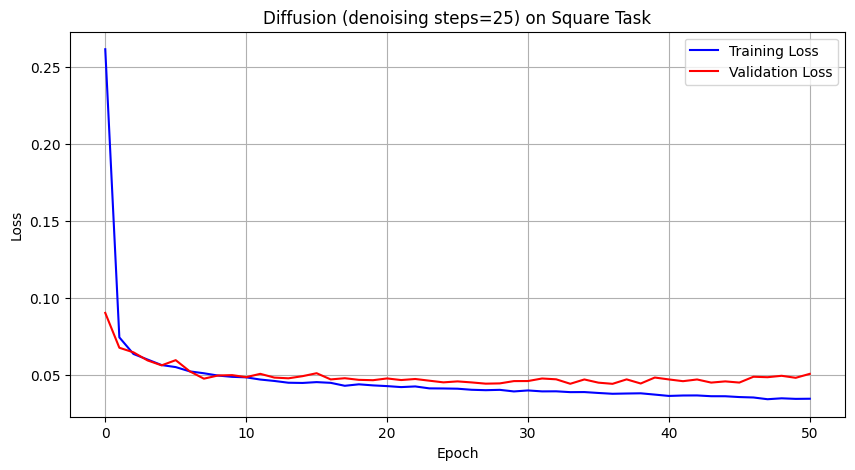

In [ ]:
from helper import load_data_for_training
obs_keys = ["object", "robot0_eef_pos", "robot0_eef_quat", "robot0_gripper_qpos"]

seq_len = 16
batch_size = 100
train_loader, valid_loader = load_data_for_training(
    dataset_path=square_path,
    obs_keys=obs_keys,
    seq_len=seq_len,
    batch_size=batch_size,
)

input_dim = 23
output_dim = 7
prediction_horizon = 16
action_horizon = 8
obs_horizon = 2
ph_model_denoise25 = DLM_Diffusion(
    output_dim = output_dim,
    input_dim = input_dim,
    denoising_steps=25,
    prediction_horizon=prediction_horizon,
    action_horizon=action_horizon,
    obs_horizon = obs_horizon
    )

from helper import train
# pred_horizon
num_epochs = 51
save_path = os.path.join(path_to_dlm, "trainings/dataset_quality_square_diffusion_denoise_25")
if not os.path.exists(save_path):
  os.makedirs(save_path)
training_losses, validation_losses = train(ph_model_denoise25, train_loader, valid_loader, num_epochs=num_epochs, save_path = save_path)

import matplotlib.pyplot as plt

train_loss_values, train_epochs = zip(*[(loss.item(), epoch) for loss, epoch in training_losses])
valid_loss_values, valid_epochs = zip(*[(loss.item(), epoch) for loss, epoch in validation_losses])


plt.figure(figsize=(10, 5))
plt.plot(train_loss_values, label='Training Loss', color='blue')
plt.plot(valid_loss_values, label='Validation Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Diffusion (denoising steps=25) on Square Task')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from helper import rollout
import imageio


num_rollouts = 50
success_rate = rollout(ph_model_denoise25,
                      dataset_path,
                      horizon = 400,
                      video_writer = None,
                      obs_keys = obs_keys,
                      num_rollouts = num_rollouts,
                      obs_len = 2)
print("Success rate over {} rollouts: {}".format(num_rollouts, success_rate))

[robosuite WARNING] No private macro file found! (macros.py:53)
[robosuite WARNING] It is recommended to use a private macro file (macros.py:54)
[robosuite WARNING] To setup, run: python /content/./robosuite/robosuite/scripts/setup_macros.py (macros.py:55)


Created environment with name NutAssemblySquare
Action size is 7
Success rate over 50 rollouts: 0.82


### Diffusion - 50 denoising steps on Proficient Human (PH) dataset

SequenceDataset: loading dataset into memory...
100%|██████████| 180/180 [00:00<00:00, 526.85it/s]
SequenceDataset: caching get_item calls...
100%|██████████| 27165/27165 [00:01<00:00, 19633.33it/s]
SequenceDataset: loading dataset into memory...
100%|██████████| 20/20 [00:00<00:00, 312.94it/s]
SequenceDataset: caching get_item calls...
100%|██████████| 2989/2989 [00:00<00:00, 13815.94it/s]
batch keys: dict_keys(['actions', 'obs'])
observation shapes: 
object shape: torch.Size([100, 16, 14])
robot0_eef_pos shape: torch.Size([100, 16, 3])
robot0_eef_quat shape: torch.Size([100, 16, 4])
robot0_gripper_qpos shape: torch.Size([100, 16, 2])
action shape: torch.Size([100, 16, 7])
number of parameters: 6.587828e+07
Epoch: 0 Train Loss: 0.25247108936309814 Valid Loss: 0.09522678703069687
Epoch: 10 Train Loss: 0.05285043269395828 Valid Loss: 0.0578654520213604
Epoch: 20 Train Loss: 0.04752189293503761 Valid Loss: 0.049234312027692795
Epoch: 30 Train Loss: 0.04365639016032219 Valid Loss: 0.05101

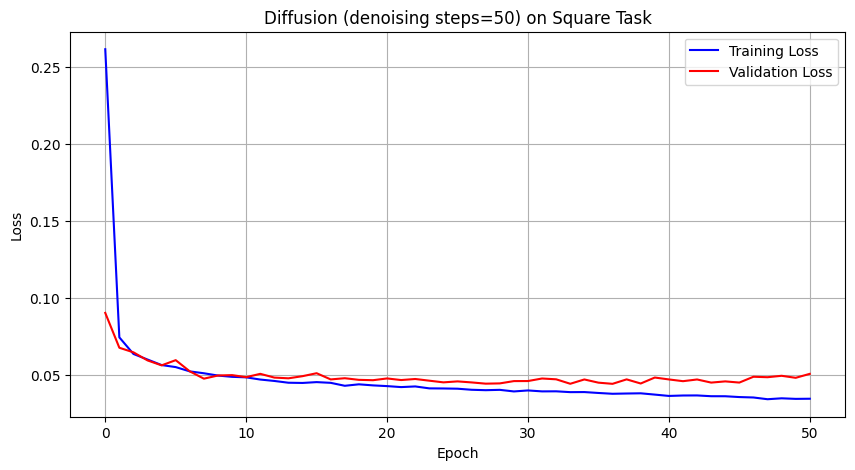

In [ ]:
from helper import load_data_for_training
obs_keys = ["object", "robot0_eef_pos", "robot0_eef_quat", "robot0_gripper_qpos"]

seq_len = 16
batch_size = 100
train_loader, valid_loader = load_data_for_training(
    dataset_path=square_path,
    obs_keys=obs_keys,
    seq_len=seq_len,
    batch_size=batch_size,
)

input_dim = 23
output_dim = 7
prediction_horizon = 16
action_horizon = 8
obs_horizon = 2
ph_model_denoise50 = DLM_Diffusion(
    output_dim = output_dim,
    input_dim = input_dim,
    denoising_steps=50,
    prediction_horizon=prediction_horizon,
    action_horizon=action_horizon,
    obs_horizon = obs_horizon
    )

from helper import train
# pred_horizon
num_epochs = 51
save_path = os.path.join(path_to_dlm, "trainings/dataset_quality_square_diffusion_denoise_50")
if not os.path.exists(save_path):
  os.makedirs(save_path)
training_losses, validation_losses = train(ph_model_denoise50, train_loader, valid_loader, num_epochs=num_epochs, save_path = save_path)

plt.figure(figsize=(10, 5))
plt.plot(train_loss_values, label='Training Loss', color='blue')
plt.plot(valid_loss_values, label='Validation Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Diffusion (denoising steps=50) on Square Task')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from helper import rollout
import imageio


num_rollouts = 50
success_rate = rollout(ph_model_denoise50,
                      dataset_path,
                      horizon = 400,
                      video_writer = None,
                      obs_keys = obs_keys,
                      num_rollouts = num_rollouts,
                      obs_len = 2)
print("Success rate over {} rollouts: {}".format(num_rollouts, success_rate))

Created environment with name NutAssemblySquare
Action size is 7
Success rate over 50 rollouts: 0.78


### Diffusion - 75 denoising steps on Proficient Human (PH) dataset

SequenceDataset: loading dataset into memory...
100%|██████████| 180/180 [00:00<00:00, 422.10it/s]
SequenceDataset: caching get_item calls...
100%|██████████| 27165/27165 [00:01<00:00, 19371.07it/s]
SequenceDataset: loading dataset into memory...
100%|██████████| 20/20 [00:00<00:00, 290.19it/s]
SequenceDataset: caching get_item calls...
100%|██████████| 2989/2989 [00:00<00:00, 18618.15it/s]
batch keys: dict_keys(['actions', 'obs'])
observation shapes: 
object shape: torch.Size([100, 16, 14])
robot0_eef_pos shape: torch.Size([100, 16, 3])
robot0_eef_quat shape: torch.Size([100, 16, 4])
robot0_gripper_qpos shape: torch.Size([100, 16, 2])
action shape: torch.Size([100, 16, 7])
number of parameters: 6.587828e+07
Epoch: 0 Train Loss: 0.2504197657108307 Valid Loss: 0.0942479744553566
Epoch: 10 Train Loss: 0.05390689894556999 Valid Loss: 0.056758660823106766
Epoch: 20 Train Loss: 0.04887717589735985 Valid Loss: 0.052211008965969086
Epoch: 30 Train Loss: 0.04684996232390404 Valid Loss: 0.05166

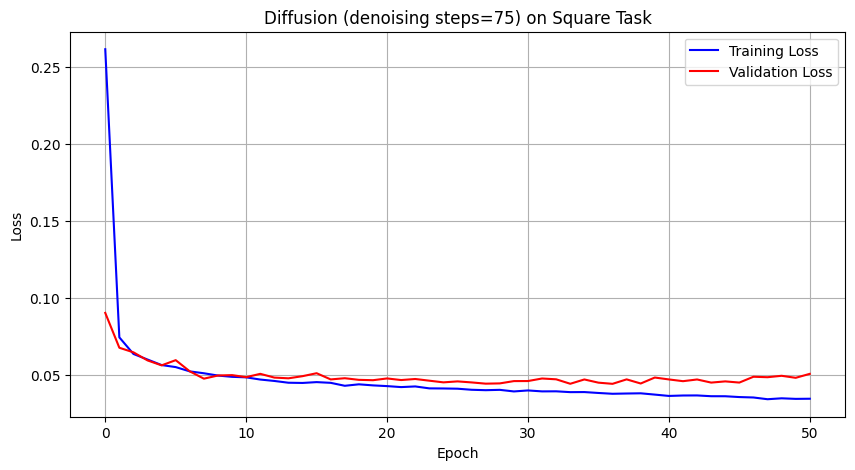

In [ ]:
from helper import load_data_for_training
obs_keys = ["object", "robot0_eef_pos", "robot0_eef_quat", "robot0_gripper_qpos"]

seq_len = 16
batch_size = 100
train_loader, valid_loader = load_data_for_training(
    dataset_path=square_path,
    obs_keys=obs_keys,
    seq_len=seq_len,
    batch_size=batch_size,
)

input_dim = 23
output_dim = 7
prediction_horizon = 16
action_horizon = 8
obs_horizon = 2
ph_model_denoise75 = DLM_Diffusion(
    output_dim = output_dim,
    input_dim = input_dim,
    denoising_steps=75,
    prediction_horizon=prediction_horizon,
    action_horizon=action_horizon,
    obs_horizon = obs_horizon
    )

from helper import train
# pred_horizon
num_epochs = 51
save_path = os.path.join(path_to_dlm, "trainings/dataset_quality_square_diffusion_denoise_75")
if not os.path.exists(save_path):
  os.makedirs(save_path)
training_losses, validation_losses = train(ph_model_denoise75, train_loader, valid_loader, num_epochs=num_epochs, save_path = save_path)

plt.figure(figsize=(10, 5))
plt.plot(train_loss_values, label='Training Loss', color='blue')
plt.plot(valid_loss_values, label='Validation Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Diffusion (denoising steps=75) on Square Task')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from helper import rollout
import imageio


num_rollouts = 50
success_rate = rollout(ph_model_denoise75,
                      dataset_path,
                      horizon = 400,
                      video_writer = None,
                      obs_keys = obs_keys,
                      num_rollouts = num_rollouts,
                      obs_len = 2)
print("Success rate over {} rollouts: {}".format(num_rollouts, success_rate))

Created environment with name NutAssemblySquare
Action size is 7
Success rate over 50 rollouts: 0.74


### Diffusion - 100 denoising steps on Proficient Human (PH) dataset

SequenceDataset: loading dataset into memory...
100%|██████████| 180/180 [00:01<00:00, 174.47it/s]
SequenceDataset: caching get_item calls...
100%|██████████| 27165/27165 [00:03<00:00, 7597.49it/s] 
SequenceDataset: loading dataset into memory...
100%|██████████| 20/20 [00:00<00:00, 334.08it/s]
SequenceDataset: caching get_item calls...
100%|██████████| 2989/2989 [00:00<00:00, 20015.89it/s]
batch keys: dict_keys(['actions', 'obs'])
observation shapes: 
object shape: torch.Size([100, 16, 14])
robot0_eef_pos shape: torch.Size([100, 16, 3])
robot0_eef_quat shape: torch.Size([100, 16, 4])
robot0_gripper_qpos shape: torch.Size([100, 16, 2])
action shape: torch.Size([100, 16, 7])
number of parameters: 6.587828e+07
Epoch: 0 Train Loss: 0.2901914715766907 Valid Loss: 0.09919850528240204
Epoch: 10 Train Loss: 0.056285884231328964 Valid Loss: 0.058599889278411865
Epoch: 20 Train Loss: 0.05145594850182533 Valid Loss: 0.0569901205599308
Epoch: 30 Train Loss: 0.04700168967247009 Valid Loss: 0.05253

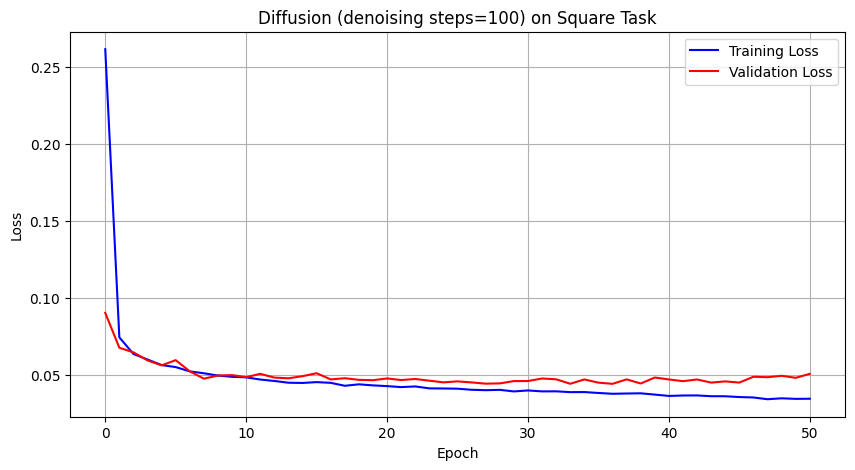

In [ ]:
from helper import load_data_for_training
obs_keys = ["object", "robot0_eef_pos", "robot0_eef_quat", "robot0_gripper_qpos"]

seq_len = 16
batch_size = 100
train_loader, valid_loader = load_data_for_training(
    dataset_path=square_path,
    obs_keys=obs_keys,
    seq_len=seq_len,
    batch_size=batch_size,
)

input_dim = 23
output_dim = 7
prediction_horizon = 16
action_horizon = 8
obs_horizon = 2
ph_model_denoise100 = DLM_Diffusion(
    output_dim = output_dim,
    input_dim = input_dim,
    denoising_steps=100,
    prediction_horizon=prediction_horizon,
    action_horizon=action_horizon,
    obs_horizon = obs_horizon
    )

from helper import train
# pred_horizon
num_epochs = 51
save_path = os.path.join(path_to_dlm, "trainings/dataset_quality_square_diffusion_denoise_100")
if not os.path.exists(save_path):
  os.makedirs(save_path)
training_losses, validation_losses = train(ph_model_denoise100, train_loader, valid_loader, num_epochs=num_epochs, save_path = save_path)

plt.figure(figsize=(10, 5))
plt.plot(train_loss_values, label='Training Loss', color='blue')
plt.plot(valid_loss_values, label='Validation Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Diffusion (denoising steps=100) on Square Task')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from helper import rollout
import imageio


num_rollouts = 50
success_rate = rollout(ph_model_denoise100,
                      dataset_path,
                      horizon = 400,
                      video_writer = None,
                      obs_keys = obs_keys,
                      num_rollouts = num_rollouts,
                      obs_len = 2)
print("Success rate over {} rollouts: {}".format(num_rollouts, success_rate))

Created environment with name NutAssemblySquare
Action size is 7
Success rate over 50 rollouts: 0.68


### Diffusion - 25 denoising steps on Multi-Human (MH) dataset

SequenceDataset: loading dataset into memory...
100%|██████████| 270/270 [00:00<00:00, 342.49it/s]
SequenceDataset: caching get_item calls...
100%|██████████| 72707/72707 [00:03<00:00, 20410.24it/s]
SequenceDataset: loading dataset into memory...
100%|██████████| 30/30 [00:00<00:00, 349.48it/s]
SequenceDataset: caching get_item calls...
100%|██████████| 8024/8024 [00:00<00:00, 20393.84it/s]
batch keys: dict_keys(['actions', 'obs'])
observation shapes: 
object shape: torch.Size([100, 16, 14])
robot0_eef_pos shape: torch.Size([100, 16, 3])
robot0_eef_quat shape: torch.Size([100, 16, 4])
robot0_gripper_qpos shape: torch.Size([100, 16, 2])
action shape: torch.Size([100, 16, 7])
number of parameters: 6.587828e+07
Epoch: 0 Train Loss: 0.12803108990192413 Valid Loss: 0.055644042789936066
Epoch: 10 Train Loss: 0.0372377410531044 Valid Loss: 0.039820779114961624
Epoch: 20 Train Loss: 0.032372165471315384 Valid Loss: 0.0372609905898571
Epoch: 30 Train Loss: 0.029068559408187866 Valid Loss: 0.040

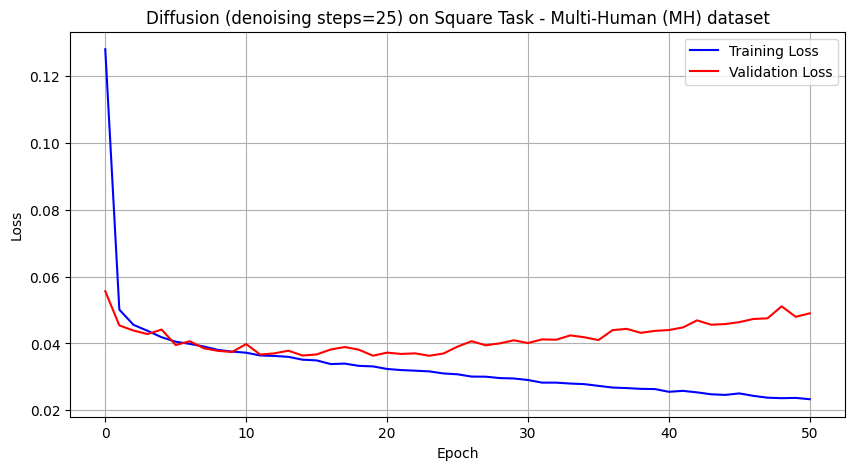

Created environment with name NutAssemblySquare
Action size is 7
Success rate over 50 rollouts: 0.76


In [ ]:
from helper import load_data_for_training
obs_keys = ["object", "robot0_eef_pos", "robot0_eef_quat", "robot0_gripper_qpos"]

seq_len = 16
batch_size = 100
train_loader, valid_loader = load_data_for_training(
    dataset_path=square_mh_path,
    obs_keys=obs_keys,
    seq_len=seq_len,
    batch_size=batch_size,
)

input_dim = 23
output_dim = 7
prediction_horizon = 16
action_horizon = 8
obs_horizon = 2
ph_model_denoise25 = DLM_Diffusion(
    output_dim = output_dim,
    input_dim = input_dim,
    denoising_steps=25,
    prediction_horizon=prediction_horizon,
    action_horizon=action_horizon,
    obs_horizon = obs_horizon
    )

from helper import train
# pred_horizon
num_epochs = 51
save_path = os.path.join(path_to_dlm, "trainings/dataset_quality_square_mh_diffusion_denoise_25")
if not os.path.exists(save_path):
  os.makedirs(save_path)
training_losses, validation_losses = train(ph_model_denoise25, train_loader, valid_loader, num_epochs=num_epochs, save_path = save_path)

import matplotlib.pyplot as plt

train_loss_values, train_epochs = zip(*[(loss.item(), epoch) for loss, epoch in training_losses])
valid_loss_values, valid_epochs = zip(*[(loss.item(), epoch) for loss, epoch in validation_losses])


plt.figure(figsize=(10, 5))
plt.plot(train_loss_values, label='Training Loss', color='blue')
plt.plot(valid_loss_values, label='Validation Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Diffusion (denoising steps=25) on Square Task - Multi-Human (MH) dataset')
plt.legend()
plt.grid(True)
plt.show()

from helper import rollout
import imageio


num_rollouts = 50
success_rate = rollout(ph_model_denoise25,
                      square_mh_path,
                      horizon = 400,
                      video_writer = None,
                      obs_keys = obs_keys,
                      num_rollouts = num_rollouts,
                      obs_len = 2)
print("Success rate over {} rollouts: {}".format(num_rollouts, success_rate))

### Diffusion - 50 denoising steps on Multi-Human (MH) dataset

SequenceDataset: loading dataset into memory...
100%|██████████| 270/270 [00:00<00:00, 366.80it/s]
SequenceDataset: caching get_item calls...
100%|██████████| 72707/72707 [00:03<00:00, 20698.33it/s]
SequenceDataset: loading dataset into memory...
100%|██████████| 30/30 [00:00<00:00, 313.93it/s]
SequenceDataset: caching get_item calls...
100%|██████████| 8024/8024 [00:00<00:00, 20086.36it/s]
batch keys: dict_keys(['actions', 'obs'])
observation shapes: 
object shape: torch.Size([100, 16, 14])
robot0_eef_pos shape: torch.Size([100, 16, 3])
robot0_eef_quat shape: torch.Size([100, 16, 4])
robot0_gripper_qpos shape: torch.Size([100, 16, 2])
action shape: torch.Size([100, 16, 7])
number of parameters: 6.587828e+07
Epoch: 0 Train Loss: 0.1338122934103012 Valid Loss: 0.06103986129164696
Epoch: 10 Train Loss: 0.04157068580389023 Valid Loss: 0.043079398572444916
Epoch: 20 Train Loss: 0.03681075572967529 Valid Loss: 0.04007399454712868
Epoch: 30 Train Loss: 0.033073052763938904 Valid Loss: 0.0439

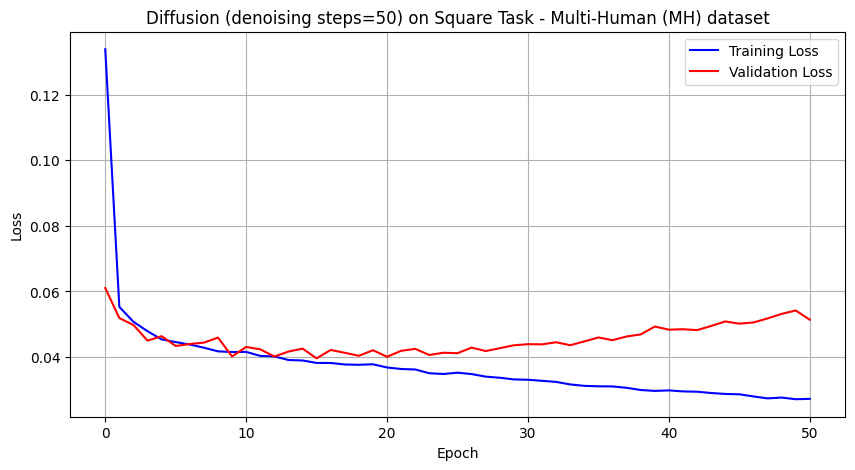

Created environment with name NutAssemblySquare
Action size is 7
Success rate over 50 rollouts: 0.74


In [ ]:
from helper import load_data_for_training
obs_keys = ["object", "robot0_eef_pos", "robot0_eef_quat", "robot0_gripper_qpos"]

seq_len = 16
batch_size = 100
train_loader, valid_loader = load_data_for_training(
    dataset_path=square_mh_path,
    obs_keys=obs_keys,
    seq_len=seq_len,
    batch_size=batch_size,
)

input_dim = 23
output_dim = 7
prediction_horizon = 16
action_horizon = 8
obs_horizon = 2
ph_model_denoise50 = DLM_Diffusion(
    output_dim = output_dim,
    input_dim = input_dim,
    denoising_steps=50,
    prediction_horizon=prediction_horizon,
    action_horizon=action_horizon,
    obs_horizon = obs_horizon
    )

from helper import train
# pred_horizon
num_epochs = 51
save_path = os.path.join(path_to_dlm, "trainings/dataset_quality_square_mh_diffusion_denoise_50")
if not os.path.exists(save_path):
  os.makedirs(save_path)
training_losses, validation_losses = train(ph_model_denoise50, train_loader, valid_loader, num_epochs=num_epochs, save_path = save_path)

train_loss_values, train_epochs = zip(*[(loss.item(), epoch) for loss, epoch in training_losses])
valid_loss_values, valid_epochs = zip(*[(loss.item(), epoch) for loss, epoch in validation_losses])

plt.figure(figsize=(10, 5))
plt.plot(train_loss_values, label='Training Loss', color='blue')
plt.plot(valid_loss_values, label='Validation Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Diffusion (denoising steps=50) on Square Task - Multi-Human (MH) dataset')
plt.legend()
plt.grid(True)
plt.show()

from helper import rollout
import imageio


num_rollouts = 50
success_rate = rollout(ph_model_denoise50,
                      square_mh_path,
                      horizon = 400,
                      video_writer = None,
                      obs_keys = obs_keys,
                      num_rollouts = num_rollouts,
                      obs_len = 2)
print("Success rate over {} rollouts: {}".format(num_rollouts, success_rate))

### Diffusion - 75 denoising steps on Multi-Human (MH) dataset

SequenceDataset: loading dataset into memory...
100%|██████████| 270/270 [00:00<00:00, 338.46it/s]
SequenceDataset: caching get_item calls...
100%|██████████| 72707/72707 [00:03<00:00, 20794.75it/s]
SequenceDataset: loading dataset into memory...
100%|██████████| 30/30 [00:00<00:00, 279.60it/s]
SequenceDataset: caching get_item calls...
100%|██████████| 8024/8024 [00:00<00:00, 20241.34it/s]
batch keys: dict_keys(['actions', 'obs'])
observation shapes: 
object shape: torch.Size([100, 16, 14])
robot0_eef_pos shape: torch.Size([100, 16, 3])
robot0_eef_quat shape: torch.Size([100, 16, 4])
robot0_gripper_qpos shape: torch.Size([100, 16, 2])
action shape: torch.Size([100, 16, 7])
number of parameters: 6.587828e+07
Epoch: 0 Train Loss: 0.13971738517284393 Valid Loss: 0.06390877813100815
Epoch: 10 Train Loss: 0.04289877787232399 Valid Loss: 0.04470435529947281
Epoch: 20 Train Loss: 0.03822160139679909 Valid Loss: 0.041367605328559875
Epoch: 30 Train Loss: 0.03467489778995514 Valid Loss: 0.0441

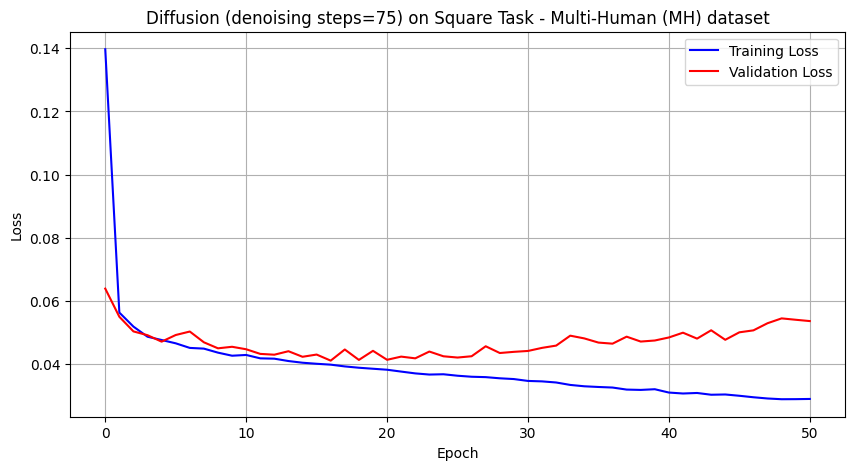

Created environment with name NutAssemblySquare
Action size is 7
Success rate over 50 rollouts: 0.62


In [ ]:
from helper import load_data_for_training
obs_keys = ["object", "robot0_eef_pos", "robot0_eef_quat", "robot0_gripper_qpos"]

seq_len = 16
batch_size = 100
train_loader, valid_loader = load_data_for_training(
    dataset_path=square_mh_path,
    obs_keys=obs_keys,
    seq_len=seq_len,
    batch_size=batch_size,
)

input_dim = 23
output_dim = 7
prediction_horizon = 16
action_horizon = 8
obs_horizon = 2
ph_model_denoise75 = DLM_Diffusion(
    output_dim = output_dim,
    input_dim = input_dim,
    denoising_steps=75,
    prediction_horizon=prediction_horizon,
    action_horizon=action_horizon,
    obs_horizon = obs_horizon
    )

from helper import train
# pred_horizon
num_epochs = 51
save_path = os.path.join(path_to_dlm, "trainings/dataset_quality_square_mh_diffusion_denoise_75")
if not os.path.exists(save_path):
  os.makedirs(save_path)
training_losses, validation_losses = train(ph_model_denoise75, train_loader, valid_loader, num_epochs=num_epochs, save_path = save_path)

train_loss_values, train_epochs = zip(*[(loss.item(), epoch) for loss, epoch in training_losses])
valid_loss_values, valid_epochs = zip(*[(loss.item(), epoch) for loss, epoch in validation_losses])

plt.figure(figsize=(10, 5))
plt.plot(train_loss_values, label='Training Loss', color='blue')
plt.plot(valid_loss_values, label='Validation Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Diffusion (denoising steps=75) on Square Task - Multi-Human (MH) dataset')
plt.legend()
plt.grid(True)
plt.show()

from helper import rollout
import imageio


num_rollouts = 50
success_rate = rollout(ph_model_denoise75,
                      square_mh_path,
                      horizon = 400,
                      video_writer = None,
                      obs_keys = obs_keys,
                      num_rollouts = num_rollouts,
                      obs_len = 2)
print("Success rate over {} rollouts: {}".format(num_rollouts, success_rate))

### Diffusion - 100 denoising steps on Multi-Human (MH) dataset

SequenceDataset: loading dataset into memory...
100%|██████████| 270/270 [00:00<00:00, 357.79it/s]
SequenceDataset: caching get_item calls...
100%|██████████| 72707/72707 [00:03<00:00, 20112.54it/s]
SequenceDataset: loading dataset into memory...
100%|██████████| 30/30 [00:00<00:00, 267.07it/s]
SequenceDataset: caching get_item calls...
100%|██████████| 8024/8024 [00:00<00:00, 18728.84it/s]
batch keys: dict_keys(['actions', 'obs'])
observation shapes: 
object shape: torch.Size([100, 16, 14])
robot0_eef_pos shape: torch.Size([100, 16, 3])
robot0_eef_quat shape: torch.Size([100, 16, 4])
robot0_gripper_qpos shape: torch.Size([100, 16, 2])
action shape: torch.Size([100, 16, 7])
number of parameters: 6.587828e+07
Epoch: 0 Train Loss: 0.1306268870830536 Valid Loss: 0.0684184804558754
Epoch: 10 Train Loss: 0.04325874149799347 Valid Loss: 0.045282021164894104
Epoch: 20 Train Loss: 0.03889957070350647 Valid Loss: 0.04250628128647804
Epoch: 30 Train Loss: 0.03543583303689957 Valid Loss: 0.045383

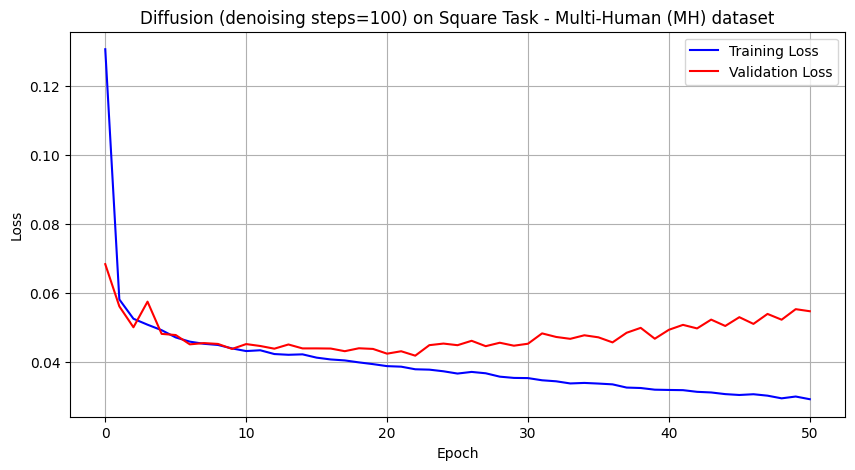

Created environment with name NutAssemblySquare
Action size is 7
Success rate over 50 rollouts: 0.7


In [ ]:
from helper import load_data_for_training
obs_keys = ["object", "robot0_eef_pos", "robot0_eef_quat", "robot0_gripper_qpos"]

seq_len = 16
batch_size = 100
train_loader, valid_loader = load_data_for_training(
    dataset_path=square_mh_path,
    obs_keys=obs_keys,
    seq_len=seq_len,
    batch_size=batch_size,
)

input_dim = 23
output_dim = 7
prediction_horizon = 16
action_horizon = 8
obs_horizon = 2
ph_model_denoise100 = DLM_Diffusion(
    output_dim = output_dim,
    input_dim = input_dim,
    denoising_steps=100,
    prediction_horizon=prediction_horizon,
    action_horizon=action_horizon,
    obs_horizon = obs_horizon
    )

from helper import train
# pred_horizon
num_epochs = 51
save_path = os.path.join(path_to_dlm, "trainings/dataset_quality_square_mh_diffusion_denoise_100")
if not os.path.exists(save_path):
  os.makedirs(save_path)
training_losses, validation_losses = train(ph_model_denoise100, train_loader, valid_loader, num_epochs=num_epochs, save_path = save_path)

train_loss_values, train_epochs = zip(*[(loss.item(), epoch) for loss, epoch in training_losses])
valid_loss_values, valid_epochs = zip(*[(loss.item(), epoch) for loss, epoch in validation_losses])

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_loss_values, label='Training Loss', color='blue')
plt.plot(valid_loss_values, label='Validation Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Diffusion (denoising steps=100) on Square Task - Multi-Human (MH) dataset')
plt.legend()
plt.grid(True)
plt.show()


from helper import rollout
import imageio


num_rollouts = 50
success_rate = rollout(ph_model_denoise100,
                      square_mh_path,
                      horizon = 400,
                      video_writer = None,
                      obs_keys = obs_keys,
                      num_rollouts = num_rollouts,
                      obs_len = 2)
print("Success rate over {} rollouts: {}".format(num_rollouts, success_rate))

**You can add however many code blocks here, but leave the most essential ones upon submission to prove your work.**


**Enter your hypotheses here:** \
 If I increase the denoising steps in diffusion policy, I will obtain a lower task success rate on both optimal (proficient human) and sub-optimal (multi-human) data.


**Enter your experiment here:** \
I tested diffusion policy with different denoising steps 25,50,75,100 on the square task from proficient human (optimal) as well as multi-human (suboptimal) datasets and compare task success rate over 50 rollouts.


**Include figures, brief explanation of the figures. You may use more than one cell**

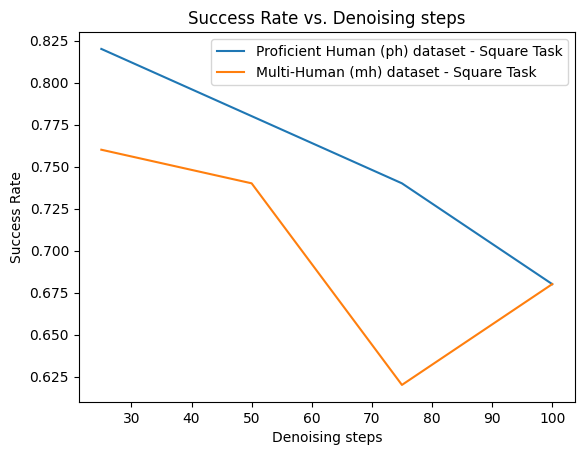

In [ ]:
import matplotlib.pyplot as plt

denoising_steps = [25, 50, 75, 100]
task_success_rate_ph = [0.82, 0.78, 0.74, 0.68]
task_success_rate_mh = [0.76, 0.74, 0.62, 0.68]

plt.plot(denoising_steps, task_success_rate_ph, label='Proficient Human (ph) dataset - Square Task')
plt.plot(denoising_steps, task_success_rate_mh, label='Multi-Human (mh) dataset - Square Task')

plt.ylabel('Success Rate')
plt.xlabel('Denoising steps')
plt.title('Success Rate vs. Denoising steps')
plt.legend()

**Enter your analysis here** (be concrete about how each result validates or invalidates your hypothesis and why): \

We utilize both optimal (proficient human) and suboptimal (multi-human) dataset to prove our hypothesis. The proficient human (ph) dataset is collected only by expert demonstrators while the multi-human (mh) dataset is collected by demonstrators of varying skills making it suboptimal.

**25 Denoising steps:**
*   The task requires precise and fine-grained manipulation, and 25 denoising steps are sufficient in completing it successfully.
*   At this stage, the **denoising steps are balanced to recover low-frequency coarse actions initially and gradually learn high-frequency fine-grained actions required for this precise manipulation task**.
*   This balance helps it to perform optimally over both ph and mh datasets instead of overfitting to minor variations/jitter in actions.



**50, 75, and 100 Denoising steps:**
*   A gradual decline in performance is observed for both proficient and multi-human setup. This is primarily because the model has begun overfitting and attempts learning high-level frequency or noisy actions in final stages of denoising.
*   There is a small increase later from 75 to 100 for mh dataset, however,overall the performance is still smaller than at 25 denoising steps which indicate a gradual decline from 25 to 100 denoising steps.
*   This validates our hypothesis that **beyond an optimal amount of denoising, any increase in denoising steps lead to decrease in performance on both optimal and suboptimal dataset.**

Overall, it supports our hypothesis that if I increase the denoising steps, I will obtain lower peformance on both optimal (proficient human) as well as suboptimal (multi-human) datasets.

The key-idea here is higher denoising steps leads to reduced downstream success rate on different quality of datasets.




## **Sequence Length/Prediction Horizon (10 PT)**



Example hypothesis: If I increase the sequence length for the RNN, I will see improved task performance on hard tasks.  Additionally, increasing the sequence length will have no affect on the performance of easy tasks.

This is more of a data loader characteristic than a dataset characteristic. But we want to make sure that you also experiment with the prediction horizons and sequence lenghts of the models.  If you choose to do this for RNN, you will just be changing with the sequence length that you pass into the data loader.  If you choose to do this for the diffusion model you should experiment with the predicion horizon and the action horizon (make sure to read the diffusion policy paper if you are unsure what this means).  You could also do this for the MLP, but you would have to change the input and output dims.

#### Tool Hang task (Hard) - Training RNNs with different sequence lengths -4, 8, 16

In [ ]:
from helper import load_data_for_training
obs_keys = ["object", "robot0_eef_pos", "robot0_eef_quat", "robot0_gripper_qpos"]
## 1. Sequence Length 4
seq_len = 4
batch_size = 100
train_loader, valid_loader = load_data_for_training(
    dataset_path=tool_hang_path,
    obs_keys=obs_keys,
    seq_len=seq_len,
    batch_size=batch_size,
)

'''
# and the prediction horizon and action horizon for diffusion model
# note that the seq_len of data loader should match the prediction_horizon
prediction_horizon = 16
action_horizon = 8
model = DLM_Diffusion(
    output_dim = output_dim,
    input_dim = input_dim,
    denoising_steps=denoising_steps,
    prediction_horizon=prediction_horizon,
    action_horizon=action_horizon,
    obs_horizon = obs_horizon
    )
'''

input_dim = 53
output_dim = 7
hidden_dim = 400
num_layers = 2
# make sure rnn_horizon is same as dataloader sequence length
rnn_horizon = 4
rnn_small_horizon_model = DLM_RNN(input_dim = input_dim, hidden_dim = hidden_dim, num_layers = num_layers, output_dim = output_dim, obs_keys = obs_keys, rnn_horizon = rnn_horizon)

from helper import train

# model epochs saved to save_path/epoch_x.pth where x is every 50 epochs
save_path = os.path.join(path_to_dlm, "trainings/rnn_seq_len_4_tool_hang")
if not os.path.exists(save_path):
  os.makedirs(save_path)


from helper import train

num_epochs = 501
train_losses_rnn_4, valid_losses_rnn_4 = train(
                                  rnn_small_horizon_model,
                                  train_loader,
                                  valid_loader,
                                  num_epochs=num_epochs,
                                  save_path=save_path
                                )





## 2. Sequence Length 8
seq_len = 8
train_loader, valid_loader = load_data_for_training(
    dataset_path=tool_hang_path,
    obs_keys=obs_keys,
    seq_len=seq_len,
    batch_size=batch_size,
)


rnn_horizon = 8
rnn_medium_horizon_model = DLM_RNN(input_dim = input_dim, hidden_dim = hidden_dim, num_layers = num_layers, output_dim = output_dim, obs_keys = obs_keys, rnn_horizon = rnn_horizon)

from helper import train

# model epochs saved to save_path/epoch_x.pth where x is every 50 epochs
save_path = os.path.join(path_to_dlm, "trainings/rnn_seq_len_8_tool_hang")
if not os.path.exists(save_path):
  os.makedirs(save_path)


from helper import train

num_epochs = 501
train_losses_rnn_8, valid_losses_rnn_8 = train(
                                  rnn_medium_horizon_model,
                                  train_loader,
                                  valid_loader,
                                  num_epochs=num_epochs,
                                  save_path=save_path
                                )


## 3. Sequence Length 16
seq_len = 16
train_loader, valid_loader = load_data_for_training(
    dataset_path=tool_hang_path,
    obs_keys=obs_keys,
    seq_len=seq_len,
    batch_size=batch_size,
)


rnn_horizon = 16
rnn_large_horizon_model = DLM_RNN(input_dim = input_dim, hidden_dim = hidden_dim, num_layers = num_layers, output_dim = output_dim, obs_keys = obs_keys, rnn_horizon = rnn_horizon)

from helper import train

# model epochs saved to save_path/epoch_x.pth where x is every 50 epochs
save_path = os.path.join(path_to_dlm, "trainings/rnn_seq_len_16_tool_hang")
if not os.path.exists(save_path):
  os.makedirs(save_path)


from helper import train

num_epochs = 501
train_losses_rnn_16, valid_losses_rnn_16 = train(
                                  rnn_large_horizon_model,
                                  train_loader,
                                  valid_loader,
                                  num_epochs=num_epochs,
                                  save_path=save_path
                                )


SequenceDataset: loading dataset into memory...
100%|██████████| 180/180 [00:00<00:00, 350.38it/s]
SequenceDataset: caching get_item calls...
100%|██████████| 86336/86336 [00:03<00:00, 21797.76it/s]
SequenceDataset: loading dataset into memory...
100%|██████████| 20/20 [00:00<00:00, 336.93it/s]
SequenceDataset: caching get_item calls...
100%|██████████| 9626/9626 [00:00<00:00, 24974.51it/s]
batch keys: dict_keys(['actions', 'obs'])
observation shapes: 
object shape: torch.Size([100, 4, 44])
robot0_eef_pos shape: torch.Size([100, 4, 3])
robot0_eef_quat shape: torch.Size([100, 4, 4])
robot0_gripper_qpos shape: torch.Size([100, 4, 2])
action shape: torch.Size([100, 4, 7])
Epoch: 0 Train Loss: 0.09945005923509598 Valid Loss: 0.06337226927280426
Epoch: 10 Train Loss: 0.03363453224301338 Valid Loss: 0.03340423107147217
Epoch: 20 Train Loss: 0.02970738708972931 Valid Loss: 0.03103727102279663
Epoch: 30 Train Loss: 0.027183962985873222 Valid Loss: 0.028406094759702682
Epoch: 40 Train Loss: 0.0

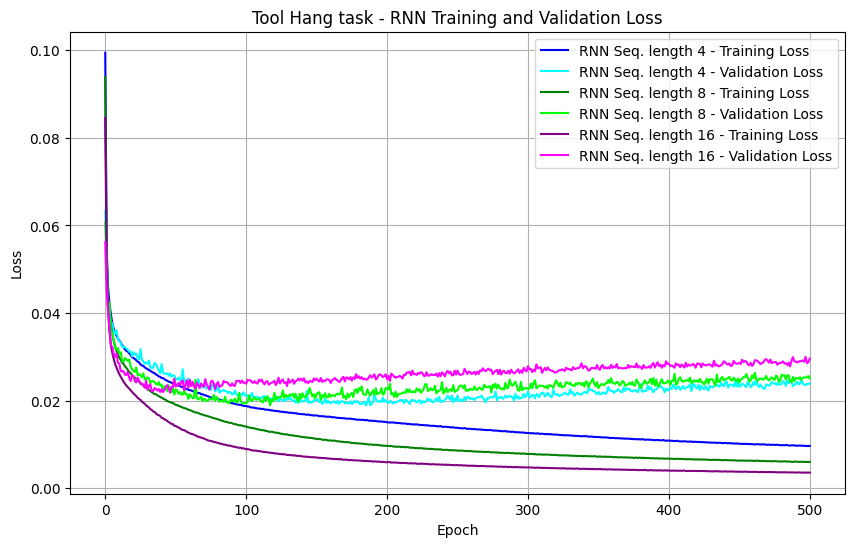

In [ ]:
import matplotlib.pyplot as plt

# Unpack the tuples into lists for plotting
train_loss_values_rnn4, train_epochs = zip(*[(loss.item(), epoch) for loss, epoch in train_losses_rnn_4])
valid_loss_values_rnn4, valid_epochs = zip(*[(loss.item(), epoch) for loss, epoch in valid_losses_rnn_4])

train_loss_values_rnn8, train_epochs = zip(*[(loss.item(), epoch) for loss, epoch in train_losses_rnn_8])
valid_loss_values_rnn8, valid_epochs = zip(*[(loss.item(), epoch) for loss, epoch in valid_losses_rnn_8])

train_loss_values_rnn16, train_epochs = zip(*[(loss.item(), epoch) for loss, epoch in train_losses_rnn_16])
valid_loss_values_rnn16, valid_epochs = zip(*[(loss.item(), epoch) for loss, epoch in valid_losses_rnn_16])

# Plotting
plt.figure(figsize=(10, 6))  # Set the figure size for better readability
plt.plot(train_epochs, train_loss_values_rnn4, label='RNN Seq. length 4 - Training Loss', color='blue')
plt.plot(valid_epochs, valid_loss_values_rnn4, label='RNN Seq. length 4 - Validation Loss', color='cyan')

plt.plot(train_epochs, train_loss_values_rnn8, label='RNN Seq. length 8 - Training Loss', color='green')
plt.plot(valid_epochs, valid_loss_values_rnn8, label='RNN Seq. length 8 - Validation Loss', color='lime')

plt.plot(train_epochs, train_loss_values_rnn16, label='RNN Seq. length 16 - Training Loss', color='purple')
plt.plot(valid_epochs, valid_loss_values_rnn16, label='RNN Seq. length 16 - Validation Loss', color='magenta')

# Adding title and labels
plt.title('Tool Hang task - RNN Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()  # Show legend to differentiate between training and validation loss

# Show grid for easier visualization
plt.grid(True)

# Display the plot
plt.show()

#### NutAssemblySquare - Training RNNs with different sequence lengths - 4, 8, 16

In [ ]:
from helper import load_data_for_training
obs_keys = ["object", "robot0_eef_pos", "robot0_eef_quat", "robot0_gripper_qpos"]
## 1. Sequence Length 4
seq_len = 4
batch_size = 100
train_loader, valid_loader = load_data_for_training(
    dataset_path=square_path,
    obs_keys=obs_keys,
    seq_len=seq_len,
    batch_size=batch_size,
)


input_dim = 23
output_dim = 7
hidden_dim = 400
num_layers = 2
# make sure rnn_horizon is same as dataloader sequence length
rnn_horizon = 4
rnn_small_horizon_model = DLM_RNN(input_dim = input_dim, hidden_dim = hidden_dim, num_layers = num_layers, output_dim = output_dim, obs_keys = obs_keys, rnn_horizon = rnn_horizon)

from helper import train

# model epochs saved to save_path/epoch_x.pth where x is every 50 epochs
save_path = os.path.join(path_to_dlm, "trainings/rnn_seq_len_4_square")
if not os.path.exists(save_path):
  os.makedirs(save_path)


from helper import train

num_epochs = 501
train_losses_rnn_4, valid_losses_rnn_4 = train(
                                  rnn_small_horizon_model,
                                  train_loader,
                                  valid_loader,
                                  num_epochs=num_epochs,
                                  save_path=save_path
                                )





## 2. Sequence Length 8
seq_len = 8
train_loader, valid_loader = load_data_for_training(
    dataset_path=square_path,
    obs_keys=obs_keys,
    seq_len=seq_len,
    batch_size=batch_size,
)


rnn_horizon = 8
rnn_medium_horizon_model = DLM_RNN(input_dim = input_dim, hidden_dim = hidden_dim, num_layers = num_layers, output_dim = output_dim, obs_keys = obs_keys, rnn_horizon = rnn_horizon)

from helper import train

# model epochs saved to save_path/epoch_x.pth where x is every 50 epochs
save_path = os.path.join(path_to_dlm, "trainings/rnn_seq_len_8_square")
if not os.path.exists(save_path):
  os.makedirs(save_path)


from helper import train

num_epochs = 501
train_losses_rnn_8, valid_losses_rnn_8 = train(
                                  rnn_medium_horizon_model,
                                  train_loader,
                                  valid_loader,
                                  num_epochs=num_epochs,
                                  save_path=save_path
                                )


## 3. Sequence Length 16
seq_len = 16
train_loader, valid_loader = load_data_for_training(
    dataset_path=square_path,
    obs_keys=obs_keys,
    seq_len=seq_len,
    batch_size=batch_size,
)


rnn_horizon = 16
rnn_large_horizon_model = DLM_RNN(input_dim = input_dim, hidden_dim = hidden_dim, num_layers = num_layers, output_dim = output_dim, obs_keys = obs_keys, rnn_horizon = rnn_horizon)

from helper import train

# model epochs saved to save_path/epoch_x.pth where x is every 50 epochs
save_path = os.path.join(path_to_dlm, "trainings/rnn_seq_len_16_square")
if not os.path.exists(save_path):
  os.makedirs(save_path)


from helper import train

num_epochs = 501
train_losses_rnn_16, valid_losses_rnn_16 = train(
                                  rnn_large_horizon_model,
                                  train_loader,
                                  valid_loader,
                                  num_epochs=num_epochs,
                                  save_path=save_path
                                )

SequenceDataset: loading dataset into memory...
100%|██████████| 180/180 [00:00<00:00, 475.85it/s]
SequenceDataset: caching get_item calls...
100%|██████████| 27165/27165 [00:01<00:00, 22746.85it/s]
SequenceDataset: loading dataset into memory...
100%|██████████| 20/20 [00:00<00:00, 314.86it/s]
SequenceDataset: caching get_item calls...
100%|██████████| 2989/2989 [00:00<00:00, 19923.87it/s]
batch keys: dict_keys(['actions', 'obs'])
observation shapes: 
object shape: torch.Size([100, 4, 14])
robot0_eef_pos shape: torch.Size([100, 4, 3])
robot0_eef_quat shape: torch.Size([100, 4, 4])
robot0_gripper_qpos shape: torch.Size([100, 4, 2])
action shape: torch.Size([100, 4, 7])
Epoch: 0 Train Loss: 0.18060314655303955 Valid Loss: 0.15669354796409607
Epoch: 10 Train Loss: 0.058796077966690063 Valid Loss: 0.06439872086048126
Epoch: 20 Train Loss: 0.05203050374984741 Valid Loss: 0.059921666979789734
Epoch: 30 Train Loss: 0.04876238852739334 Valid Loss: 0.05315108224749565
Epoch: 40 Train Loss: 0.0

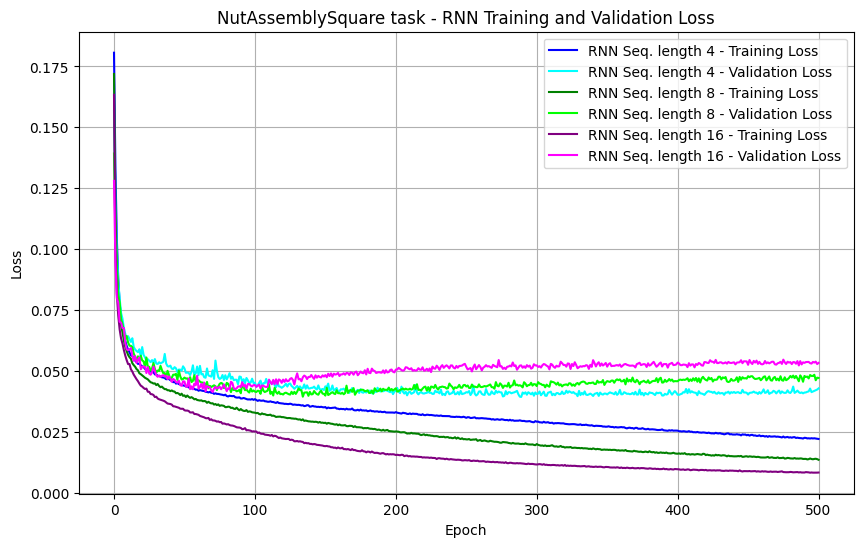

In [ ]:
import matplotlib.pyplot as plt

# Unpack the tuples into lists for plotting
train_loss_values_rnn4, train_epochs = zip(*[(loss.item(), epoch) for loss, epoch in train_losses_rnn_4])
valid_loss_values_rnn4, valid_epochs = zip(*[(loss.item(), epoch) for loss, epoch in valid_losses_rnn_4])

train_loss_values_rnn8, train_epochs = zip(*[(loss.item(), epoch) for loss, epoch in train_losses_rnn_8])
valid_loss_values_rnn8, valid_epochs = zip(*[(loss.item(), epoch) for loss, epoch in valid_losses_rnn_8])

train_loss_values_rnn16, train_epochs = zip(*[(loss.item(), epoch) for loss, epoch in train_losses_rnn_16])
valid_loss_values_rnn16, valid_epochs = zip(*[(loss.item(), epoch) for loss, epoch in valid_losses_rnn_16])

# Plotting
plt.figure(figsize=(10, 6))  # Set the figure size for better readability
plt.plot(train_epochs, train_loss_values_rnn4, label='RNN Seq. length 4 - Training Loss', color='blue')
plt.plot(valid_epochs, valid_loss_values_rnn4, label='RNN Seq. length 4 - Validation Loss', color='cyan')

plt.plot(train_epochs, train_loss_values_rnn8, label='RNN Seq. length 8 - Training Loss', color='green')
plt.plot(valid_epochs, valid_loss_values_rnn8, label='RNN Seq. length 8 - Validation Loss', color='lime')

plt.plot(train_epochs, train_loss_values_rnn16, label='RNN Seq. length 16 - Training Loss', color='purple')
plt.plot(valid_epochs, valid_loss_values_rnn16, label='RNN Seq. length 16 - Validation Loss', color='magenta')

# Adding title and labels
plt.title('NutAssemblySquare task - RNN Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()  # Show legend to differentiate between training and validation loss

# Show grid for easier visualization
plt.grid(True)

# Display the plot
plt.show()

#### Lift task (Easy) - Training RNNs with different sequence lengths -4, 8, 16

In [ ]:
from helper import load_data_for_training
obs_keys = ["object", "robot0_eef_pos", "robot0_eef_quat", "robot0_gripper_qpos"]
## 1. Sequence Length 4
seq_len = 4
batch_size = 100
train_loader, valid_loader = load_data_for_training(
    dataset_path=lift_path,
    obs_keys=obs_keys,
    seq_len=seq_len,
    batch_size=batch_size,
)


input_dim = 19
output_dim = 7
hidden_dim = 400
num_layers = 2
# make sure rnn_horizon is same as dataloader sequence length
rnn_horizon = 4
rnn_small_horizon_model = DLM_RNN(input_dim = input_dim, hidden_dim = hidden_dim, num_layers = num_layers, output_dim = output_dim, obs_keys = obs_keys, rnn_horizon = rnn_horizon)

from helper import train

# model epochs saved to save_path/epoch_x.pth where x is every 50 epochs
save_path = os.path.join(path_to_dlm, "trainings/rnn_seq_len_4_lift")
if not os.path.exists(save_path):
  os.makedirs(save_path)


from helper import train

num_epochs = 501
train_losses_rnn_4, valid_losses_rnn_4 = train(
                                  rnn_small_horizon_model,
                                  train_loader,
                                  valid_loader,
                                  num_epochs=num_epochs,
                                  save_path=save_path
                                )





## 2. Sequence Length 8
seq_len = 8
train_loader, valid_loader = load_data_for_training(
    dataset_path=lift_path,
    obs_keys=obs_keys,
    seq_len=seq_len,
    batch_size=batch_size,
)


rnn_horizon = 8
rnn_medium_horizon_model = DLM_RNN(input_dim = input_dim, hidden_dim = hidden_dim, num_layers = num_layers, output_dim = output_dim, obs_keys = obs_keys, rnn_horizon = rnn_horizon)

from helper import train

# model epochs saved to save_path/epoch_x.pth where x is every 50 epochs
save_path = os.path.join(path_to_dlm, "trainings/rnn_seq_len_8_lift")
if not os.path.exists(save_path):
  os.makedirs(save_path)


from helper import train

num_epochs = 501
train_losses_rnn_8, valid_losses_rnn_8 = train(
                                  rnn_medium_horizon_model,
                                  train_loader,
                                  valid_loader,
                                  num_epochs=num_epochs,
                                  save_path=save_path
                                )


## 3. Sequence Length 16
seq_len = 16
train_loader, valid_loader = load_data_for_training(
    dataset_path=lift_path,
    obs_keys=obs_keys,
    seq_len=seq_len,
    batch_size=batch_size,
)


rnn_horizon = 16
rnn_large_horizon_model = DLM_RNN(input_dim = input_dim, hidden_dim = hidden_dim, num_layers = num_layers, output_dim = output_dim, obs_keys = obs_keys, rnn_horizon = rnn_horizon)

from helper import train

# model epochs saved to save_path/epoch_x.pth where x is every 50 epochs
save_path = os.path.join(path_to_dlm, "trainings/rnn_seq_len_16_lift")
if not os.path.exists(save_path):
  os.makedirs(save_path)


from helper import train

num_epochs = 501
train_losses_rnn_16, valid_losses_rnn_16 = train(
                                  rnn_large_horizon_model,
                                  train_loader,
                                  valid_loader,
                                  num_epochs=num_epochs,
                                  save_path=save_path
                                )

SequenceDataset: loading dataset into memory...
100%|██████████| 180/180 [00:00<00:00, 611.49it/s]
SequenceDataset: caching get_item calls...
100%|██████████| 8640/8640 [00:00<00:00, 22210.72it/s]
SequenceDataset: loading dataset into memory...
100%|██████████| 20/20 [00:00<00:00, 446.58it/s]
SequenceDataset: caching get_item calls...
100%|██████████| 1026/1026 [00:00<00:00, 20153.12it/s]
batch keys: dict_keys(['actions', 'obs'])
observation shapes: 
object shape: torch.Size([100, 4, 10])
robot0_eef_pos shape: torch.Size([100, 4, 3])
robot0_eef_quat shape: torch.Size([100, 4, 4])
robot0_gripper_qpos shape: torch.Size([100, 4, 2])
action shape: torch.Size([100, 4, 7])
Epoch: 0 Train Loss: 0.18829885125160217 Valid Loss: 0.1746644377708435
Epoch: 10 Train Loss: 0.06430009752511978 Valid Loss: 0.06434421241283417
Epoch: 20 Train Loss: 0.04305671155452728 Valid Loss: 0.04260293021798134
Epoch: 30 Train Loss: 0.037755582481622696 Valid Loss: 0.03556394949555397
Epoch: 40 Train Loss: 0.03557

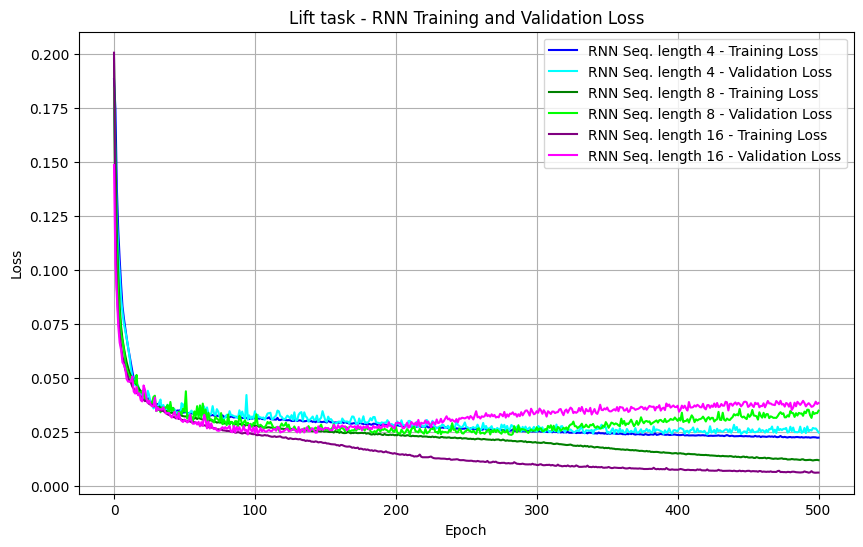

In [ ]:
import matplotlib.pyplot as plt

# Unpack the tuples into lists for plotting
train_loss_values_rnn4, train_epochs = zip(*[(loss.item(), epoch) for loss, epoch in train_losses_rnn_4])
valid_loss_values_rnn4, valid_epochs = zip(*[(loss.item(), epoch) for loss, epoch in valid_losses_rnn_4])

train_loss_values_rnn8, train_epochs = zip(*[(loss.item(), epoch) for loss, epoch in train_losses_rnn_8])
valid_loss_values_rnn8, valid_epochs = zip(*[(loss.item(), epoch) for loss, epoch in valid_losses_rnn_8])

train_loss_values_rnn16, train_epochs = zip(*[(loss.item(), epoch) for loss, epoch in train_losses_rnn_16])
valid_loss_values_rnn16, valid_epochs = zip(*[(loss.item(), epoch) for loss, epoch in valid_losses_rnn_16])

# Plotting
plt.figure(figsize=(10, 6))  # Set the figure size for better readability
plt.plot(train_epochs, train_loss_values_rnn4, label='RNN Seq. length 4 - Training Loss', color='blue')
plt.plot(valid_epochs, valid_loss_values_rnn4, label='RNN Seq. length 4 - Validation Loss', color='cyan')

plt.plot(train_epochs, train_loss_values_rnn8, label='RNN Seq. length 8 - Training Loss', color='green')
plt.plot(valid_epochs, valid_loss_values_rnn8, label='RNN Seq. length 8 - Validation Loss', color='lime')

plt.plot(train_epochs, train_loss_values_rnn16, label='RNN Seq. length 16 - Training Loss', color='purple')
plt.plot(valid_epochs, valid_loss_values_rnn16, label='RNN Seq. length 16 - Validation Loss', color='magenta')

# Adding title and labels
plt.title('Lift task - RNN Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()  # Show legend to differentiate between training and validation loss

# Show grid for easier visualization
plt.grid(True)

# Display the plot
plt.show()

### TODO:

**You can add however many code blocks here, but leave the most essential ones upon submission to prove your work.**


#### Success rates for NutAssemblySquare, Lift and Tool hang task across different sequence lengths in RNN

Created environment with name NutAssemblySquare
Action size is 7
Created environment with name Lift
Action size is 7
Created environment with name ToolHang
Action size is 7
Created environment with name NutAssemblySquare
Action size is 7
Created environment with name Lift
Action size is 7
Created environment with name ToolHang
Action size is 7
Created environment with name NutAssemblySquare
Action size is 7
Created environment with name Lift
Action size is 7
Created environment with name ToolHang
Action size is 7


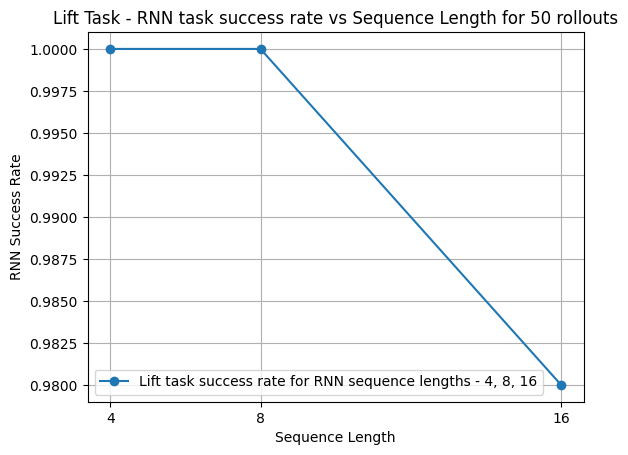

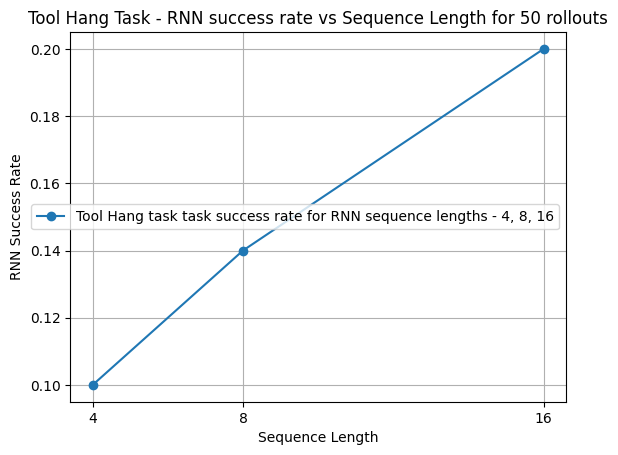

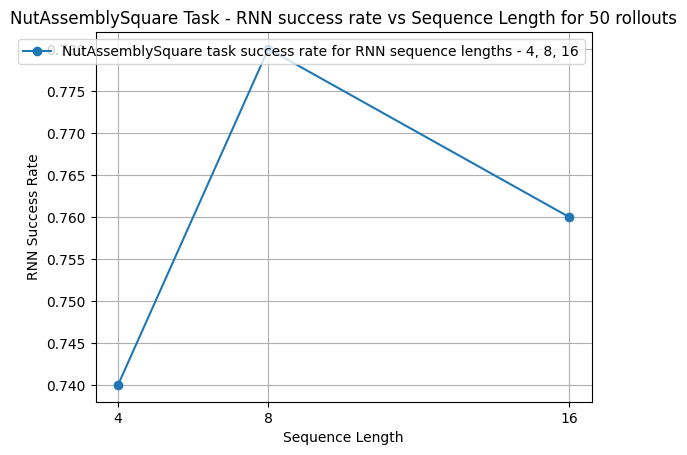

In [ ]:
from helper import load_data_for_training
from helper import rollout
from matplotlib import pyplot as plt
import os

rollouts = 50
seq_lengths = [4, 8, 16]
hidden_dim = 400
num_layers = 2
batch_size = 100
obs_keys = ["object", "robot0_eef_pos", "robot0_eef_quat", "robot0_gripper_qpos"]
output_dim = 7

lift_input_dim = 19
lift_task_success_rate = []

tool_hang_input_dim = 53
tool_hang_task_success_rate = []

square_input_dim = 23
square_task_success_rate = []

for seq_len in seq_lengths:
    rnn_horizon = seq_len  # Adjust horizon based on seq_len

    # Nut Assembly Square Task
    save_path = os.path.join(path_to_dlm, f"trainings/rnn_seq_len_{seq_len}_square")
    square_rnn_model = DLM_RNN(input_dim=square_input_dim, hidden_dim=hidden_dim, num_layers=num_layers, output_dim=output_dim, obs_keys=obs_keys, rnn_horizon=rnn_horizon)
    square_rnn_model.load(os.path.join(save_path, "epoch_400.pth"))
    square_task_success_rate.append(rollout(square_rnn_model,
                                           square_path,
                                           horizon=800,
                                           video_writer=None,
                                           obs_keys=obs_keys,
                                           num_rollouts=rollouts))

    # Lift Task
    save_path = os.path.join(path_to_dlm, f"trainings/rnn_seq_len_{seq_len}_lift")
    lift_rnn_model = DLM_RNN(input_dim=lift_input_dim, hidden_dim=hidden_dim, num_layers=num_layers, output_dim=output_dim, obs_keys=obs_keys, rnn_horizon=rnn_horizon)
    lift_rnn_model.load(os.path.join(save_path, "epoch_400.pth"))
    lift_task_success_rate.append(rollout(lift_rnn_model,
                                          lift_path,
                                          horizon=800,
                                          video_writer=None,
                                          obs_keys=obs_keys,
                                          num_rollouts=rollouts))

    # Tool Hang Task
    save_path = os.path.join(path_to_dlm, f"trainings/rnn_seq_len_{seq_len}_tool_hang")
    tool_hang_rnn_model = DLM_RNN(input_dim=tool_hang_input_dim, hidden_dim=hidden_dim, num_layers=num_layers, output_dim=output_dim, obs_keys=obs_keys, rnn_horizon=rnn_horizon)
    tool_hang_rnn_model.load(os.path.join(save_path, "epoch_400.pth"))
    tool_hang_task_success_rate.append(rollout(tool_hang_rnn_model,
                                               tool_hang_path,
                                               horizon=800,
                                               video_writer=None,
                                               obs_keys=obs_keys,
                                               num_rollouts=rollouts))


plt.plot(seq_lengths, lift_task_success_rate, marker='o', label='Lift task success rate for RNN sequence lengths - 4, 8, 16')
plt.xlabel('Sequence Length')
plt.ylabel('RNN Success Rate')
plt.title('Lift Task - RNN task success rate vs Sequence Length for 50 rollouts')
plt.xticks(seq_lengths)
plt.grid(True)
plt.legend()
plt.show()

plt.plot(seq_lengths, tool_hang_task_success_rate, marker='o', label='Tool Hang task task success rate for RNN sequence lengths - 4, 8, 16')
plt.xlabel('Sequence Length')
plt.ylabel('RNN Success Rate')
plt.title('Tool Hang Task - RNN success rate vs Sequence Length for 50 rollouts')
plt.xticks(seq_lengths)
plt.grid(True)
plt.legend()
plt.show()

plt.plot(seq_lengths, square_task_success_rate, marker='o', label='NutAssemblySquare task success rate for RNN sequence lengths - 4, 8, 16')
plt.xlabel('Sequence Length')
plt.ylabel('RNN Success Rate')
plt.title('NutAssemblySquare Task - RNN success rate vs Sequence Length for 50 rollouts')
plt.xticks(seq_lengths)
plt.grid(True)
plt.legend()
plt.show()

**Enter your hypotheses here:** If I increase the sequence length for the RNN, I will see improved task performance on hard tasks. Additionally, increasing the sequence length will have no affect on the performance of easy tasks.


**Enter your experiment here:** I experimented with sequence lengths of 4, 8, and 16 for all 3 tasks - lift, square and tool hang task on the proficient human (ph) dataset. For each of these tasks, we compare the task success rate for each sequence length.


**Enter your analysis here** (be concrete about how each result validates or invalidates your hypothesis and why):

**RNN Horizon 4:**
*   **Lift:** The Lift is an easy task. Hence, **the horizon of 4 is sufficient to learn this simple motion** and the single-hidden layer 1024-dim model achieves a **100%** success rate.
*   **Square**: For a single-hidden layer of 1024-dim, our RNN model with short horizon of 4 is able to achieve **74%** success rate. We observed that for this configuration of square task, the network did not improve above this performance in terms of hyperparameter tuning or specific epoch. Hence, the performance may improve with increasing the horizon length.
* **Tool Hang**: RNN with a short horizon of 4 RNN doesn't perform well for this task given it is complex and requires precise manipulation as compared to square and lift tasks. We achieve only **10%** showing that horizon length of 4 is insufficient to learn such complex motion, indicating that higher horizon length is required for improving  performance for this task.


**RNN Horizon 8:**
*   **Lift:** Increasing the sequence length to 8 again achieves **100%** success rate (same as sequence length of 4) and there is no effect on performance of sequence length on easy task. This concludes that sequence length of 4 and 8 are sufficient for solving this task, and increasing it further above 8 may lead to overfitting. This is consistent with our hypothesis.
*   **Square:** Doubling the sequence length to 8 increases the performance for square task from **74%** to **78%%** and is consistent with our hypothesis.
*   **Tool Hang:** It follows the same trend as the square task as the performance increases from **10** to **14%** by increasing the sequence length to 8. It is again consistent with our hypothesis that increasing sequence  length helps on harder tasks.


**RNN Horizon 16:**
*   **Lift:** As analyzed from previous iteration, the network starts to overfit when sequence length is increased to **16**, reducing the performance to **98%**. Given lift is an easy task, the network now starts picking up minor variations or noise from the data and overfitting to it.
*   **Square:** A similar trend is followed for square task as the performance drops by **2%** suggesting the start of overfitting. I ran multiple experiments to confirm if this was not due to some underlying stochasticity related to hyperparameter tuning or epoch selection, however, in each of the runs, I found a minor drop similar to here, hinting the start of overfitting meaning the network will now overfit for this task if we increase the sequence length.
*   **Tool Hang:** The network's success rate again improves from **14** to **20%** for the tool hang task on increasing the sequence length to 16. This is again consistent with the hypothesis that performance improves for harder tasks with increasing sequence lengths.

From the graphs and our analysis, we validate our hypothesis. The performance for hard tasks like square and tool hang increases with higher sequence length. On the opposite hand, we do not observe difference in performance initially when increasing sequence length for easy tasks like lift, and it overfits if we increase the sequence lengths further. A similar trend of overfitting is also observed for the square task.



 -----------------

## TODO - Submit to Gradescope
This is the end of the assignment

**Please download this notebook as a PDF and submit to gradescope**

Make sure you have not deleted any cell outputs that have final answers/success rates

------

Written by Matthew Bronars